<a href="https://colab.research.google.com/github/Arsenii-S7/stepik-DS-ML/blob/main/%D0%92%D0%B2%D0%B5%D0%B4%D0%B5%D0%BD%D0%B8%D0%B5_%D0%B2_DS_%D0%B8_ML(%D0%A0%D0%B5%D1%88%D0%B0%D1%8E%D1%89%D0%B8%D0%B5_%D0%B4%D0%B5%D1%80%D0%B5%D0%B2%D1%8C%D1%8F).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌳 Тема 2.1 и 2.2: Решающие деревья, энтропия и снижение неопределённости

## 🧠 Идея решающих деревьев

Решающее дерево — это способ последовательно задавать вопросы (условия на признаки), чтобы разделить данные на **чистые** группы, где преобладает один класс.  

**Пример из жизни:** угадать загаданного музыканта Beatles (Джон, Пол, Джордж, Ринго) с помощью вопросов «он носит очки?», «у него длинные волосы?». Каждый вопрос уменьшает неопределённость.

---

## 📐 Энтропия — мера неопределённости (беспорядка)

Энтропия показывает, насколько «смешаны» классы в наборе данных.  

**Формула для двух классов (Отрицательный / Положительный):**
> **H = – (p_neg * log2(p_neg)) – (p_pos * log2(p_pos))**

* **p_neg** — доля отрицательных объектов в узле.
* **p_pos** — доля положительных объектов в узле.
* **log2** — логарифм по основанию 2.

---

### 📐 Свойства энтропии:
* **Чистый узел** (все объекты одного класса) → **H = 0**.
* **Полное смешение** (50% на 50%) → **H = 1** (максимум для двух классов).
* Чем ближе распределение к равномерному (равному соотношению классов), тем выше энтропия.

---

### 🧪 Примеры расчёта:
* Доля класса 1.0 (100% одного класса) → **H = 0**
* Доля класса 0.75 (75% на 25%) → **H ≈ 0.811**
* Доля класса 0.5 (50% на 50%) → **H = 1.0**


---

## 📉 Информационный выигрыш (Information Gain)

Показывает, насколько **уменьшилась энтропия** после разделения данных по конкретному признаку.

**Формула:**
> **IG = H_parent – Sum( (n_child / n_parent) * H_child )**

* **H_parent** — энтропия исходного (родительского) узла.
* **n_parent** — общее количество объектов в родительском узле.
* **n_child** — количество объектов в конкретной дочерней ветке.
* **H_child** — энтропия этой дочерней ветки.
* **Sum** — знак суммы (складываются значения для всех получившихся веток).

Алгоритм выбирает тот признак и тот порог разделения, которые дают **максимальный информационный выигрыш**.

---

### 🧪 Пример вычисления:

* **Энтропия корня:** 1.0 (всего 8 объектов: 4 одного класса и 4 другого).
* **Разбиение по признаку X1:**
  * **Левая ветка** (4 объекта, соотношение 3 и 1): энтропия равна **0.811**
  * **Правая ветка** (4 объекта, соотношение 1 и 3): энтропия равна **0.811**
  * **Средневзвешенная энтропия после разбиения:** (4/8 * 0.811) + (4/8 * 0.811) = **0.811**
  * **Итоговый выигрыш:** IG = 1.0 – 0.811 = **0.189**

* Разбиение по признаку X2 даёт точно такой же выигрыш, поэтому дерево может выбрать любой из этих двух признаков для первого сплита.


---
## 🧪 Альтернативный критерий: индекс Джини (Gini impurity)

Индекс Джини — это тоже мера неопределённости, но она вычисляется быстрее, так как не требует расчёта логарифмов.

**Общая формула:**
> **G = 1 – Sum( (p_i)^2 )**

**Формула для двух классов:**
> **G = 1 – ( (p_neg)^2 + (p_pos)^2 )**

* **p_neg** — доля отрицательных объектов в узле.
* **p_pos** — доля положительных объектов в узле.

---

### 📐 Свойства индекса Джини:
* **Чистый узел** (все объекты одного класса) → **G = 0**.
* **Максимум при смешении 50/50** → **G = 0.5**.

Индекс Джини и энтропия в большинстве случаев приводят к построению очень похожих решающих деревьев.

## 🐍 Реализация решающего дерева в scikit‑learn

```python
from sklearn.tree import DecisionTreeClassifier

# X — матрица признаков, y — вектор целевой переменной
clf = DecisionTreeClassifier(criterion='entropy')   # Можно указать 'entropy' или 'gini'
clf.fit(X, y)
```


In [ ]:
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline





In [ ]:
from IPython.display import SVG, display, HTML
from graphviz import Source

# Увеличение размера отображаемых SVG-графиков
style = "<style>svg{width:70%; height:70%; }</style>"
HTML(style)

In [ ]:
data = pd.DataFrame({
    'X_1': [1, 1, 1, 0, 0, 0, 0, 1],
    'X_2': [0, 0, 0, 1, 0, 0, 0, 1],
    'Y':  [1, 1, 1, 1, 0, 0, 0, 0]
})

data.head(8)

,X_1,X_2,Y
0,1,0,1
1,1,0,1
2,1,0,1
3,0,1,1
4,0,0,0
5,0,0,0
6,0,0,0
7,1,1,0


In [ ]:
#создаем дерево решений
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf

DecisionTreeClassifier()

In [ ]:
X = data[['X_1', 'X_2']]
y = data.Y

In [ ]:
# обучим наше дерево решений, теперь у нас есть данные
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)


DecisionTreeClassifier(criterion='entropy')

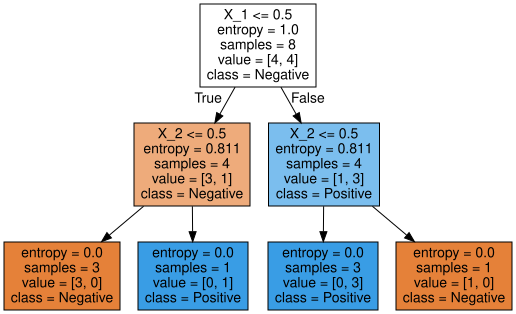

In [ ]:
# cls – обученная модель DecisionTreeClassifier
graph = Source(tree.export_graphviz(clf, out_file=None,
                                    feature_names=list(X),           # имена признаков (берём из DataFrame)
                                    class_names=['Negative','Positive'], # названия классов
                                    filled=True))                    # цветная заливка узлов
display(SVG(graph.pipe(format='svg')))

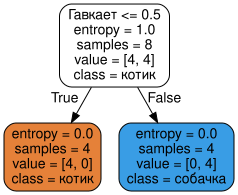

In [ ]:
# тема 2.2
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from graphviz import Source
from IPython.display import SVG, display


# Представьте, что вы решили научить робота для животных отличать собачек от котиков.
# Для начала проанализируем данные - отметьте все верные утверждения о данном датафрэйме
# Создаём DataFrame вручную на основе данных из условия
dogs_cats1 = pd.read_csv('https://stepik.org/media/attachments/course/4852/dogs.csv')
dogs_cats1.head()

X = dogs_cats1[['Гавкает', 'Лазает по деревьям']]
y = dogs_cats1['Вид']




clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# print("Важность признаков:", clf.feature_importances_)

# Визуализация
graph_data = export_graphviz(clf, out_file=None,
                             feature_names=X.columns.tolist(),
                             class_names=['котик', 'собачка'],
                             filled=True, rounded=True)
src = Source(graph_data)
display(SVG(src.pipe(format='svg')))

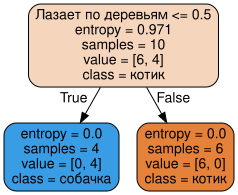

In [ ]:
# тема 2.2
dogs_cats2 = pd.read_csv('https://stepik.org/media/attachments/course/4852/cats.csv')
dogs_cats2.head(10)


X = dogs_cats2[['Гавкает', 'Лазает по деревьям']]
y = dogs_cats2['Вид']




clf = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf.fit(X, y)

# print("Важность признаков:", clf.feature_importances_)

# Визуализация
graph_data = export_graphviz(clf, out_file=None,
                             feature_names=X.columns.tolist(),
                             class_names=['котик', 'собачка'],
                             filled=True, rounded=True)
src = Source(graph_data)
display(SVG(src.pipe(format='svg')))


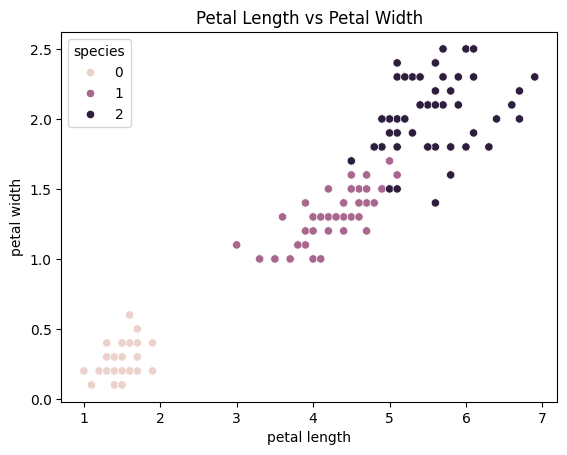

In [ ]:

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

iris_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/iris.csv')

petal_group = iris_data[['petal length', 'petal width', 'species']]

sns.scatterplot(data=iris_data, x='petal length', y='petal width', hue='species')
plt.title('Petal Length vs Petal Width')
plt.show()

# 🚢 Тема 2.3 Титаник: Machine Learning from Disaster — предсказание выживших

In [ ]:
from sklearn import tree
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline



from IPython.display import SVG, display, HTML
from graphviz import Source

# Увеличение размера отображаемых SVG-графиков
style = "<style>svg{width:70%; height:70%; }</style>"
HTML(style)

In [ ]:
# загрузим файл из kaggle
from google.colab import files
uploaded = files.upload()   #  файл train.csv





Saving train.csv to train.csv


In [ ]:
import pandas as pd

titanic_data = pd.read_csv('train.csv')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# для начала посмотрим какие данные имеют значение NaNб то есть не содержат значимости при обучении модели

titanic_data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
# уберем переменные таблицы данных, которые не сильно влияют на обучение

X = titanic_data.drop(['PassengerId','Survived', 'Name', 'Ticket', 'Cabin' ], axis = 1 )


# axis = 1 по колонкам
# почему мы удалили 'Survived'? мы хотим ее предсказывать, поэтому в переменой с фичами она не нужна

# сохраним в y ту перменную, которую хотим предсказать
y = titanic_data['Survived']

X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,S
1,1,female,38.0,1,0,71.2833,C
2,3,female,26.0,0,0,7.9250,S
3,1,female,35.0,1,0,53.1000,S
4,3,male,35.0,0,0,8.0500,S


# 🔢 `pd.get_dummies()` — one-hot encoding категориальных переменных

## 🎯 Зачем нужно?

Большинство моделей машинного обучения (например, решающие деревья, логистическая регрессия) работают только с числами. `get_dummies` преобразует категориальные переменные (например, `"male"`, `"female"` или `"S"`, `"C"`, `"Q"`) в бинарные (0/1) столбцы — по одному на каждую категорию.

## 🧠 Принцип работы

Для столбца с `k` уникальными значениями создаётся `k` новых столбцов. В каждой строке 1 ставится в том столбце, который соответствует значению в исходной переменной, в остальных — 0. Это называется **one-hot encoding**.

## 📌 Синтаксис

```python
pd.get_dummies(data, columns=None, drop_first=False, prefix=None, dtype=int)

In [ ]:
#  для обработки с помощью clf = tree.DecisionTreeClassifier() необходимо убрать
# все строковые значения, то есть заменить на формат 1 и 0
X = pd.get_dummies(X, dtype=int)
X.head()


,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,3,22.0,1,0,7.2500,0,1,0,0,1
1,1,38.0,1,0,71.2833,1,0,1,0,0
2,3,26.0,0,0,7.9250,1,0,0,0,1
3,1,35.0,1,0,53.1000,1,0,0,0,1
4,3,35.0,0,0,8.0500,0,1,0,0,1


In [ ]:


# Заполняем пропуски в Age медианой возраста всех пассажиров
median_age = X['Age'].median()
X['Age'].fillna(median_age, inplace=True)



/tmp/ipykernel_9935/534535302.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X['Age'].fillna(median_age, inplace=True)


In [ ]:
X.isnull().sum()

,0
Pclass,0
Age,0
SibSp,0
Parch,0
Fare,0
Sex_female,0
Sex_male,0
Embarked_C,0
Embarked_Q,0
Embarked_S,0


In [ ]:
clf = tree.DecisionTreeClassifier(criterion='entropy')
clf.fit(X, y)

DecisionTreeClassifier(criterion='entropy')

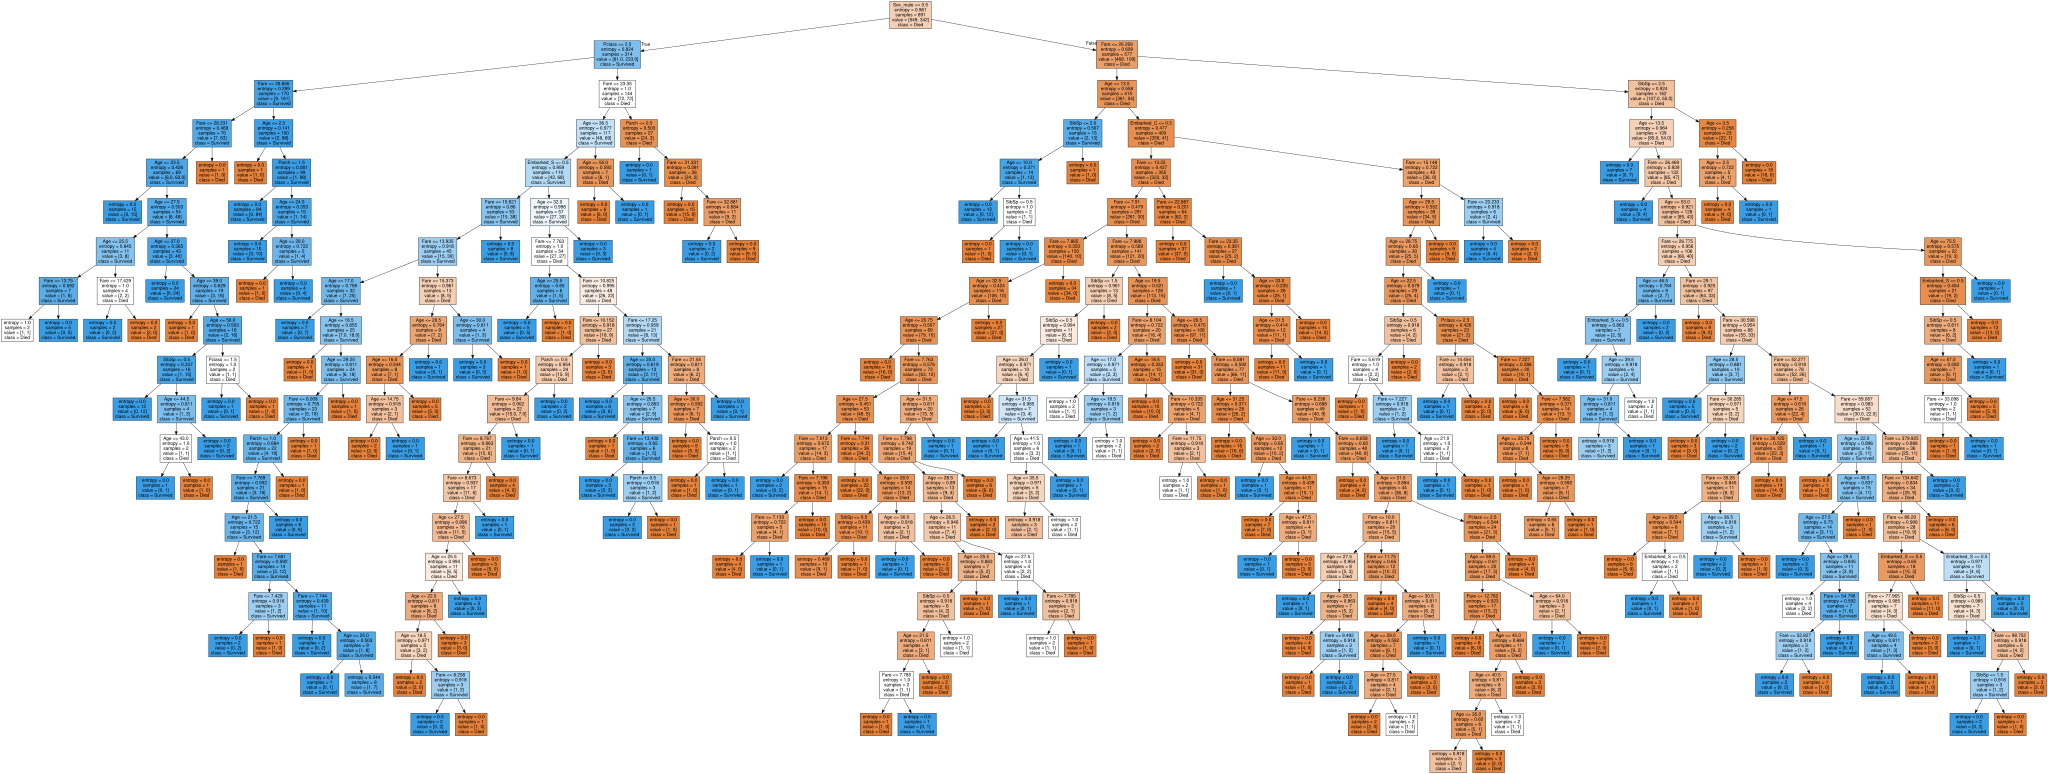

In [ ]:
# Визуализация дерева
graph = Source(tree.export_graphviz(clf, out_file=None,
                                    feature_names=list(X.columns),
                                    class_names=['Died', 'Survived'],
                                    filled=True))
display(SVG(graph.pipe(format='svg')))


# мы видим, что дерево разраслось до неверочтных размеров
# дерево сделало максимальное количество сплитов для того, чтобы уменьшить энтропию
# мы затратили больше ресурсов на разделение до полной определенности нежели на классификацию, котрая поможет понять - выжил или нет
# это называется overfitting - мы переобучили нашу модель

In [ ]:
# рассмотрим как задать определенные границы нашему дереву
# это необходимо для определения более четких закономерностей

from sklearn.model_selection import train_test_split

# Разделяем на обучающую и тестовую (опционально)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
X_train.shape

(596, 10)

In [ ]:
X_test.shape

(295, 10)

In [ ]:
clf.fit(X_train, y_train)

#  Оцениваем точность на обучающей выборке
train_accuracy = clf.score(X_train, y_train)

print(f"Точность на обучающей выборке: {train_accuracy:.4f}")


Точность на обучающей выборке: 0.9799


In [ ]:
#  Оцениваем точность на тестовой выборке
test_accuracy = clf.score(X_test, y_test)
print(f"Точность на тестовой выборке:  {test_accuracy:.4f}")


Точность на тестовой выборке:  0.7864


# ✂️ `train_test_split` — разделение данных на обучающую и тестовую выборки

## 🎯 Зачем это нужно?

Модель машинного обучения должна не только запоминать примеры из тренировочного набора, но и **хорошо работать на новых, невиданных данных**. Если оценивать модель на тех же данных, на которых она обучалась, мы получим завышенную (оптимистичную) оценку — это называется **переобучением** (overfitting).

Разделение исходных данных на две части позволяет объективно проверить качество модели:
- **Обучающая выборка (train)** — на ней модель учится (подбирает параметры).
- **Тестовая выборка (test)** — на ней модель проверяется (оценивается точность, recall и т.д.). Модель эти данные **не видела** в процессе обучения.

## 📌 Типичный код

```python
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [ ]:
clf = tree.DecisionTreeClassifier(criterion='entropy',max_depth =5)
clf.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5)

In [ ]:
train_accuracy2 = clf.score(X_train, y_train)
#  Оцениваем точность на обучающей выборке после изменения глубины max_depth=5
print(f"Точность на обучающей выборке: {train_accuracy2:.4f}")

Точность на обучающей выборке: 0.8406


In [ ]:
#  Оцениваем точность на тестовой выборке после изменения глубины max_depth=5
test_accuracy2 = clf.score(X_test, y_test)
print(f"Точность на тестовой выборке:  {test_accuracy2:.4f}")

Точность на тестовой выборке:  0.8068


# ⚖️ Тема 2.4: Обучение, переобучение, недообучение и кросс-валидация

## 📌 1. Создание DataFrame

Создаём искусственный датасет scores_data

## 📌 2. Посмотрим, какие получаются значения для тренировочных и тестовых данных

Используем цикл для обхода по глубине в диапозоне от 1 до 100 не включительно



## 📌 3. Визуализируем с помощью `lineplot`

Строим график: по оси X — глубина модели (max_depth), по оси Y — тренировочные и тестовые значения. Две линии: train и test. Наглядно видим участки недообучения, оптимальной сложности и переобучения.  


In [ ]:
from sklearn import tree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split


# Разделяем на обучающую и тестовую (опционально)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Наш DataFrame
scores_data = pd.DataFrame()

# Значения для глубины
max_depth_values = range(1,100)
records = []   # список для хранения словарей

# Обход через цикл
for max_depth in max_depth_values:
    clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
    clf.fit(X_train, y_train)

    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)

    records.append({
        'max_depth': max_depth,
        'train_score': train_score,
        'test_score': test_score
    })

# После цикла создаём DataFrame
scores_data = pd.DataFrame(records)


In [ ]:
scores_data.head()

,max_depth,train_score,test_score
0,1,0.781879,0.796610
1,2,0.805369,0.776271
2,3,0.823826,0.820339
3,4,0.833893,0.823729
4,5,0.840604,0.806780


# 🔄 `pd.melt()` — преобразование DataFrame из широкого формата в длинный

## 🎯 Зачем это нужно?

Многие библиотеки визуализации (особенно `seaborn`) и инструменты для анализа данных работают с **длинным** форматом: каждая строка — одно наблюдение, а категории кодируются отдельными колонками (например, тип выборки: тренировочная / тестовая).

Широкий формат (отдельные колонки для train и test) удобен для чтения человеком, но неудобен для построения групповых графиков. `melt` помогает быстро переформатировать данные.

## 📌 Пример из задачи

У нас есть `scores_data`:

| max_depth | train_score | test_score |
|-----------|-------------|------------|
| 1         | 0.78        | 0.80       |
| 2         | 0.81        | 0.78       |
| ...       | ...         | ...        |

Чтобы построить линию train и test на одном графике с помощью `sns.lineplot`, нужно, чтобы в одной колонке были значения метрик, а в другой — индикатор `'train'` / `'test'`. `melt` делает это:

```python
scores_long = pd.melt(scores_data,
                      id_vars=['max_depth'],          # что оставляем как есть
                      value_vars=['train_score', 'test_score'],  # что преобразуем
                      var_name='set_type',            # имя новой колонки с категориями
                      value_name='score')             # имя колонки со значениями

In [ ]:
scores_data_long = pd.melt(scores_data,
                      id_vars=['max_depth'],          # что оставляем как есть
                      value_vars=['train_score', 'test_score'],  # что преобразуем
                      var_name='set_type',            # имя новой колонки с категориями
                      value_name='score')             # имя колонки со значениями

In [ ]:
scores_data_long.head()

,max_depth,set_type,score
0,1,train_score,0.781879
1,2,train_score,0.805369
2,3,train_score,0.823826
3,4,train_score,0.833893
4,5,train_score,0.840604


<Axes: xlabel='max_depth', ylabel='score'>

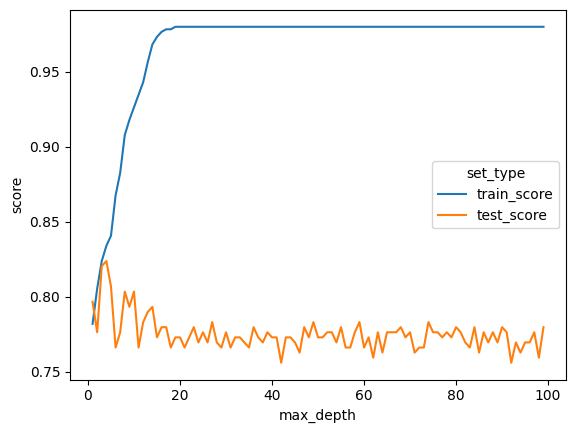

In [ ]:
# делаем визуализацию
sns.lineplot(x = 'max_depth', y ='score', hue = 'set_type', data = scores_data_long)

# 🔁 Тема 2.4: разбор **Кросс-валидация** (Cross‑Validation)

## 🎯 Зачем нужна кросс-валидация?

Обычное разделение на train/test даёт лишь одну случайную оценку качества. Модель может «повезти» или «не повезти» с конкретным разбиением.  
**Кросс-валидация** многократно повторяет разбиение и усредняет результат, давая более устойчивую оценку обобщающей способности.

## 🧠 Основная идея — K‑fold

1. Данные делятся на **K** равных частей (блоков, фолдов).
2. В каждом цикле:
   - **K-1** блоков — обучающая выборка (train)
   - **1** блок — валидационная выборка (validation)
3. Модель обучается на train, проверяется на validation, запоминается метрика (например, accuracy).
4. Процесс повторяется K раз (каждый блок побывает валидационным).
5. Итоговая оценка — **среднее арифметическое** K полученных метрик.


In [ ]:
from sklearn.model_selection import cross_val_score

clf = tree.DecisionTreeClassifier(criterion = 'entropy', max_depth=4)
cross_scores = cross_val_score(clf, X_train, y_train, cv = 5)


print("Оценки на фолдах:", cross_scores)
print(f"Средняя точность: {cross_scores.mean():.4f}")

print("Модель обучалась на 4 фолдах и проверялась на 1-м, и так 5 раз.")
print("Качество модели варьируется в зависимости от состава валидационной выборки.")

Оценки на фолдах: [0.76666667 0.82352941 0.78991597 0.75630252 0.80672269]
Средняя точность: 0.7886
Модель обучалась на 4 фолдах и проверялась на 1-м, и так 5 раз.
Качество модели варьируется в зависимости от состава валидационной выборки.


In [ ]:
# добавим еще один тип scores в наш dataframe

from sklearn import tree
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score

# Разделяем на обучающую и тестовую (опционально)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

# Наш DataFrame
scores_data = pd.DataFrame()

# Значения для глубины
max_depth_values = range(1,100)
records = []   # список для хранения словарей

# Обход через цикл
for max_depth in max_depth_values:
    clf = tree.DecisionTreeClassifier(criterion='entropy', max_depth=max_depth)
    clf.fit(X_train, y_train)
    mean_cross_scores = cross_val_score(clf, X_train, y_train, cv = 5).mean()

    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)

    records.append({
        'max_depth': max_depth,
        'train_score': train_score,
        'test_score': test_score,
        'cross_val_score': mean_cross_scores
    })

# После цикла создаём DataFrame
scores_data = pd.DataFrame(records)


In [ ]:
scores_data.head()

,max_depth,train_score,test_score,cross_val_score
0,1,0.781879,0.796610,0.781961
1,2,0.805369,0.776271,0.770196
2,3,0.823826,0.820339,0.790322
3,4,0.833893,0.823729,0.788627
4,5,0.840604,0.810169,0.803754


In [ ]:
# в ключе set_type три параметра value_vars=['train_score', 'test_score', 'cross_val_score']
scores_data_long = pd.melt(scores_data,
                      id_vars=['max_depth'],          # что оставляем как есть
                      value_vars=['train_score', 'test_score', 'cross_val_score'],  # что преобразуем
                      var_name='set_type',            # имя новой колонки с категориями
                      value_name='score')             # имя колонки со значениями

In [ ]:
scores_data_long.head()

,max_depth,set_type,score
0,1,train_score,0.781879
1,2,train_score,0.805369
2,3,train_score,0.823826
3,4,train_score,0.833893
4,5,train_score,0.840604


<Axes: xlabel='max_depth', ylabel='score'>

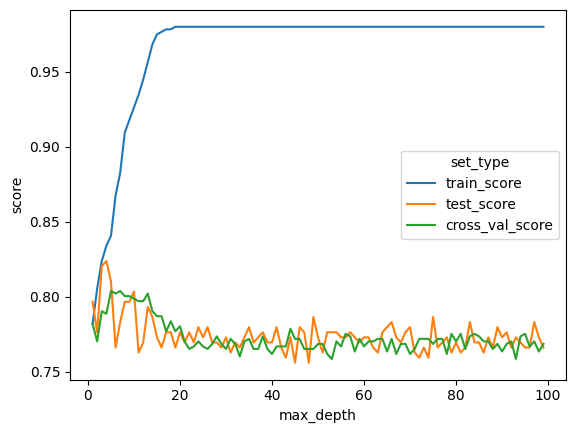

In [ ]:
# делаем визуадизацию с добавленным cross_val_score
sns.lineplot(x = 'max_depth', y ='score', hue = 'set_type', data = scores_data_long)

In [ ]:
scores_data_long.query('set_type == "cross_val_score"').head()

,max_depth,set_type,score
198,1,cross_val_score,0.781961
199,2,cross_val_score,0.770196
200,3,cross_val_score,0.790322
201,4,cross_val_score,0.788627
202,5,cross_val_score,0.803754


In [ ]:
scores_data_long.query('set_type == "cross_val_score"').max()

,0
max_depth,99
set_type,cross_val_score
score,0.803754


# 🌿 Практическое задание: переобучение и выбор глубины дерева на датасете Iris

## 🎯 Цель

На примере классического набора данных «Ирисы Фишера» мы исследуем, как изменение максимальной глубины решающего дерева (`max_depth`) влияет на качество модели. Вы увидите:
- Как точность на обучающей выборке растёт с увеличением глубины (вплоть до 100%).
- Как точность на тестовой выборке сначала улучшается, а затем начинает падать — это **переобучение**.
- Где находится оптимальная глубина, обеспечивающая наилучшее обобщение.

## 📋 Задача

1. Загрузить датасет `iris` (встроен в `sklearn.datasets`).
2. Разделить данные на **обучающую** (70–80%) и **тестовую** (20–30%) выборки.
3. Для глубины дерева от `1` до `100`:
   - Обучить `DecisionTreeClassifier(criterion='entropy', max_depth=depth, random_state=0)`.
   - Вычислить точность (`score`) на **обучающей** выборке.
   - Вычислить точность (`accuracy_score`) на **тестовой** выборке.
4. Построить график зависимости точности от глубины (две кривые: train и test).
5. Выбрать правильный вариант графика из предложенных на Stepik.

## 🛠️ Ожидаемый вид графика

- **Ось X**: `max_depth` (1 … 100)
- **Ось Y**: `accuracy` (от 0 до 1)
- **Кривая train** быстро растёт и при больших глубинах приближается к 1 (идеальное запоминание).
- **Кривая test** сначала растёт, затем стабилизируется или падает (зона переобучения).

## 💡 Подсказки

- Установите `random_state=0` в классификаторе для воспроизводимости.
- Используйте `train_test_split` с фиксированным `random_state`.
- Для ускорения можно ограничить `max_depth` до 20–30 (глубже не даст нового эффекта).
- Визуализируйте через `seaborn.lineplot` или `matplotlib`.

## ✅ Критерии успеха

- Код выполняется без ошибок.
- График явно показывает недообучение при малых глубинах и переобучение при больших.
- Выбран правильный вариант визуализации на Stepik.

> 🧠 *После выполнения задания вы сможете настраивать глубину дерева для любых данных и избегать переобучения.*

In [ ]:
import pandas as pd
import numpy as np
from sklearn import tree
# from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем обучающую и тестовую выборки
train_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/train_iris.csv')
test_data = pd.read_csv('https://stepik.org/media/attachments/course/4852/test_iris.csv')



# Разделяем признаки и целевые переменные
X_train = train_data.drop('species', axis=1)
y_train = train_data['species']
X_test = test_data.drop('species', axis=1)
y_test = test_data['species']

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)


records = []

for max_depth in range(1, 100):
    clf = DecisionTreeClassifier(criterion='entropy', max_depth=max_depth, random_state=0)
    clf.fit(X_train, y_train)

    train_score = clf.score(X_train, y_train)
    test_score = clf.score(X_test, y_test)

    records.append({
        'max_depth': max_depth,
        'train_score': train_score,
        'test_score': test_score
    })

# Создаём DataFrame после цикла
scores_data = pd.DataFrame(records)


Размер обучающей выборки: (100, 5)
Размер тестовой выборки: (50, 5)


In [ ]:
scores_data.head()

,max_depth,train_score,test_score
0,1,0.7,0.6
1,2,1.0,1.0
2,3,1.0,1.0
3,4,1.0,1.0
4,5,1.0,1.0


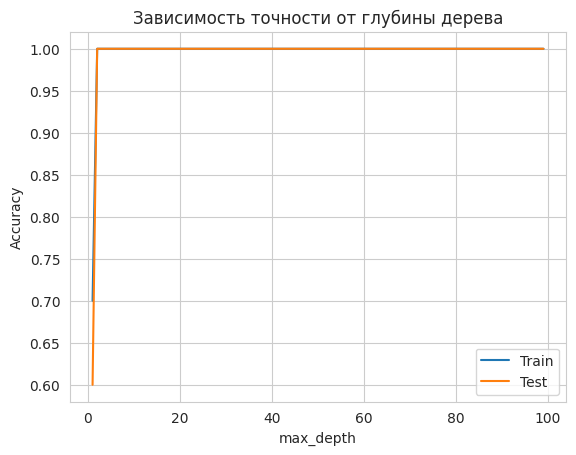

In [ ]:
# Визуализация
# Построение графика

sns.lineplot(data=scores_data, x='max_depth', y='train_score', label='Train')
sns.lineplot(data=scores_data, x='max_depth', y='test_score', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Зависимость точности от глубины дерева')
plt.legend()
plt.show()

# 🐱🐶 Практика: классификация котиков и собачек с помощью дерева решений

## 📌 Задача

1. Скачать **тренировочный датасет** (котики и собачки) — ссылка на Stepik.
2. Обучить `DecisionTreeClassifier` (можно с параметрами по умолчанию или с `random_state=42`).
3. Скачать **тестовый датасет** (в формате JSON) — кнопка «скачать набор данных» в задании.
4. Загрузить тестовый датасет через `pd.read_json()`.
5. Сделать предсказания для тестовых наблюдений.
6. Посчитать, сколько предсказанных **собачек** (определённый класс) и ввести это число в поле ответа.

In [ ]:
import pandas as pd
import numpy as np
from sklearn import tree
# from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns


train_cats_dogs = pd.read_csv('https://stepik.org/media/attachments/course/4852/dogs_n_cats.csv')

X_train = train_cats_dogs.drop('Вид', axis=1)
y_train = train_cats_dogs['Вид']
# преобразуем текстовые метки в числа, если нужно (например, 'собачка' -> 1, 'котик' -> 0)
y_train = (y_train == 'собачка').astype(int)

# Обучаем дерево решений (случайное состояние для воспроизводимости)
clf = DecisionTreeClassifier(random_state=0)
clf.fit(X_train, y_train)



DecisionTreeClassifier(random_state=0)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving dataset_209691_15 (2).txt to dataset_209691_15 (2).txt


In [ ]:

#  Загружаем тестовый набор данных (JSON) – пользователь скачивает его с Stepik
#    Предполагается, что файл называется "test_data.json" и лежит в текущей папке
test_df = pd.read_json('dataset_209691_15 (2).txt')

#  Предсказываем классы для тестовых наблюдений
predictions = clf.predict(test_df)

# Считаем количество собачек (класс 1)
dog_count = (predictions == 1).sum()
print(f"Количество собачек в тестовом наборе: {dog_count}")


Количество собачек в тестовом наборе: 53


In [ ]:
test_df.head()

,Длина,Высота,Шерстист,Гавкает,Лазает по деревьям
0,15,18.0,1,1,0
1,15,18.0,1,1,0
2,20,24.0,1,1,0
3,17,20.4,1,1,0
4,30,36.0,1,1,0


# 🔮 Метод `predict()` в scikit-learn

## 🎯 Что делает?

После обучения модели (например, `DecisionTreeClassifier`, `LogisticRegression` и др.) метод `predict()` применяет её к новым данным и возвращает **предсказанные классы** (или значения для регрессии).

## 📌 Синтаксис

```python
predictions = model.predict(X_new)

# 🎯 Тема 2.5: Метрики качества модели (последний джедай)

## 🧩 Матрица ошибок (Confusion Matrix)

Для бинарной классификации (положительный / отрицательный класс):



| | Предсказано Positive | Предсказано Negative |
| :--- | :--- | :--- |
| **Реально Positive** | TP (True Positive) | FN (False Negative) |
| **Реально Negative** | FP (False Positive) | TN (True Negative) |

* **TP** — верно предсказали положительный класс.
* **TN** — верно предсказали отрицательный класс.
* **FP** — ложная тревога (ошибка I рода).
* **FN** — пропуск цели (ошибка II рода).

---

## 📊 Основные метрики

### Точность (Accuracy)
> **Accuracy = (TP + TN) / (TP + TN + FP + FN)**

Доля правильных ответов среди всех наблюдений.  
* **Недостаток:** плохо работает при сильном дисбалансе классов (когда одного класса в данных намного больше, чем другого).

### Точность предсказания положительного класса (Precision)
> **Precision = TP / (TP + FP)**

Показывает, какая доля из всех предсказанных моделью положительных ответов действительно оказалась верной.  
* *Высокий Precision* $\rightarrow$ у модели мало ложных тревог (минимальный FP).

### Полнота (Recall, Sensitivity, True Positive Rate)
> **Recall = TP / (TP + FN)**

Показывает, какую долю из всех реальных положительных объектов модель смогла найти и классифицировать верно.  
* *Высокий Recall* $\rightarrow$ у модели мало пропусков целей (минимальный FN).

### F1-мера (F1-score)
> **F1 = 2 * (Precision * Recall) / (Precision + Recall)**

Гармоническое среднее между Precision и Recall. Данная метрика крайне полезна, когда нужно найти оптимальный баланс между точностью и полнотой.

---

## 🧪 Пример вычисления (из задачи Stepik)

Дана матрица ошибок:



| | Predicted likes (1) | Predicted dislikes (0) |
| :--- | :--- | :--- |
| **Real likes (1)** | 15 (TP) | 30 (FN) |
| **Real dislikes (0)** | 15 (FP) | 40 (TN) |

**Расчёт метрик:**
* **Precision** = 15 / (15 + 15) = 15 / 30 = **0.5**
* **Recall** = 15 / (15 + 30) = 15 / 45 ≈ **0.333**
* **F1-score** = 2 * (0.5 * 0.333) / (0.5 + 0.333) = 0.333 / 0.833 ≈ **0.4**

---

## 🐍 Код на Python (sklearn)

```python
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Формируем списки правильных ответов и предсказаний на основе матрицы
# Порядок сборки: TP (15), FN (30), FP (15), TN (40)
y_true = [1] * 15 + [1] * 30 + [0] * 15 + [0] * 40
y_pred = [1] * 15 + [0] * 30 + [1] * 15 + [0] * 40

# Выводим матрицу ошибок для проверки
print("Матрица ошибок:")
print(confusion_matrix(y_true, y_pred, labels=[1, 0]))
print("-" * 30)

# Рассчитываем и округляем метрики
print(f"Precision: {precision_score(y_true, y_pred):.3f}")
print(f"Recall: {recall_score(y_true, y_pred):.3f}")
print(f"F1-score: {f1_score(y_true, y_pred):.3f}")
```


In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Формируем списки правильных ответов и предсказаний на основе матрицы
# Порядок сборки: TP (15), FN (30), FP (15), TN (40)
y_true = [1] * 15 + [1] * 30 + [0] * 15 + [0] * 40
y_pred = [1] * 15 + [0] * 30 + [1] * 15 + [0] * 40

# Выводим матрицу ошибок для проверки
print("Матрица ошибок:")
print(confusion_matrix(y_true, y_pred, labels=[1, 0]))
print("-" * 30)

# Рассчитываем и округляем метрики
print(f"Precision: {precision_score(y_true, y_pred):.3f}")
print(f"Recall: {recall_score(y_true, y_pred):.3f}")
print(f"F1-score: {f1_score(y_true, y_pred):.3f}")

Матрица ошибок:
[[15 30]
 [15 40]]
------------------------------
Precision: 0.500
Recall: 0.333
F1-score: 0.400


In [ ]:
from sklearn.metrics import precision_score
y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]
precision_score(y_true, y_pred, average=None)


array([0.66666667, 0.        , 0.        ])

In [ ]:
from sklearn.metrics import recall_score

y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]

# recall для каждого класса (average=None)
recall_per_class = recall_score(y_true, y_pred, average=None)
print(recall_per_class)

[1. 0. 0.]


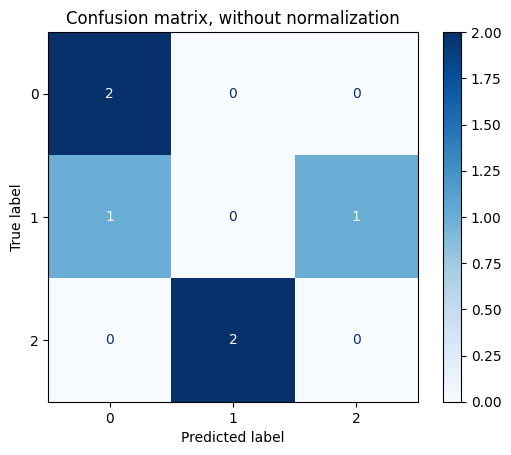

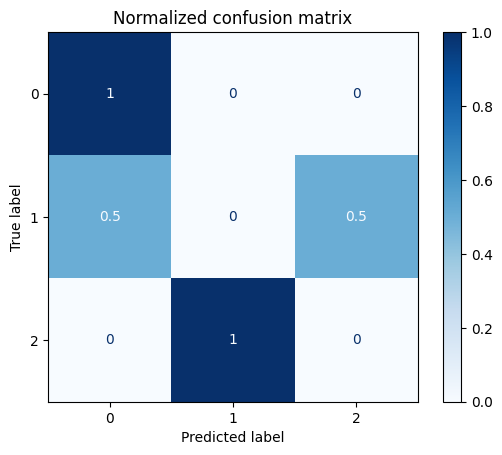

Confusion matrix, without normalization:
[[2 0 0]
 [1 0 1]
 [0 2 0]]

Normalized confusion matrix:
[[1.  0.  0. ]
 [0.5 0.  0.5]
 [0.  1.  0. ]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]
labels = [0, 1, 2]

# Обычная (ненормализованная) матрица
disp = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels, cmap=plt.cm.Blues)
plt.title("Confusion matrix, without normalization")
plt.show()

# Нормализованная матрица (по строкам)
disp_norm = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=labels, cmap=plt.cm.Blues, normalize='true')
plt.title("Normalized confusion matrix")
plt.show()

# Вывод значений
print("Confusion matrix, without normalization:")
print(disp.confusion_matrix)
print("\nNormalized confusion matrix:")
print(disp_norm.confusion_matrix)

# 📊 Объяснение матриц ошибок для примера

## Исходные данные
- Истинные классы: `y_true = [0, 1, 2, 0, 1, 2]`
- Предсказанные классы: `y_pred = [0, 2, 1, 0, 0, 1]`
- Всего 6 объектов.

## 1. Ненормализованная матрица ошибок (Confusion Matrix)

\[
\begin{matrix}
2 & 0 & 0 \\
1 & 0 & 1 \\
0 & 2 & 0
\end{matrix}
\]



**Как читать:**
- Строки → реальные классы (True)
- Столбцы → предсказанные классы (Predicted)

### Разбор по строкам (реальным классам)

**Строка 0 (реальный класс 0):**
- 2 объекта предсказаны как класс 0 (правильно)
- 0 как класс 1
- 0 как класс 2
→ **Все объекты класса 0 распознаны верно** (нет ошибок).

**Строка 1 (реальный класс 1):**
- 1 объект предсказан как класс 0 (ошибка)
- 0 как класс 1 (правильно)
- 1 как класс 2 (ошибка)
→ **Ни одного правильного предсказания для класса 1** (оба объекта ошибочны).

**Строка 2 (реальный класс 2):**
- 0 как класс 0
- 2 как класс 1 (ошибка)
- 0 как класс 2
→ **Все объекты класса 2 предсказаны неверно** (как класс 1).

## 2. Нормализованная матрица по строкам (показывает Recall)

Нормализация по строкам: каждый элемент строки делится на сумму по строке (общее количество реальных объектов этого класса). На диагонали получаем **recall** (долю правильно распознанных объектов класса).




\[
\begin{matrix}
1.0 & 0   & 0   \\
0.5 & 0   & 0.5 \\
0   & 1.0 & 0
\end{matrix}
\]



**Как читать:**

- **Строка 0 (класс 0):**  
  - 100% предсказано как класс 0 → recall = 1.0 (все распознаны).

- **Строка 1 (класс 1):**  
  - 50% предсказано как класс 0, 50% как класс 2.  
  - Доля правильных предсказаний (на диагонали) = 0.0 → recall = 0.0 (ни одного верного).

- **Строка 2 (класс 2):**  
  - 100% предсказано как класс 1.  
  - На диагонали 0.0 → recall = 0.0 (все неверны).

**Таким образом, нормализованная матрица даёт наглядное представление о полноте (recall) для каждого класса и о том, как ошибочные предсказания распределяются между другими классами.**  
(Для получения precision нужно нормализовать по столбцам.)

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Данные
y_true = [0, 1, 2, 0, 1, 2]
y_pred = [0, 2, 1, 0, 0, 1]
labels = [0, 1, 2]

# Строим матрицу ошибок (ненормализованную)
cm = confusion_matrix(y_true, y_pred, labels=labels)
print("Матрица ошибок (ненормализованная):")
print(cm)

# Нормализация по столбцам (чтобы получить precision для каждого класса)
# Для каждого столбца j: cm[i,j] / sum(cm[:,j])
# Используем np.where, чтобы избежать деления на ноль.
col_sums = cm.sum(axis=0)
# Избегаем деления на ноль: если сумма столбца 0, то нормализованное значение = 0
precision_matrix = np.divide(cm, col_sums, out=np.zeros_like(cm, dtype=float), where=col_sums != 0)

print("\nНормализованная матрица по столбцам (precision для каждого класса на диагонали):")
print(np.round(precision_matrix, 4))

# Диагональные элементы – precision
precision_per_class = precision_matrix.diagonal()
print("\nPrecision для каждого класса:")
for i, prec in enumerate(precision_per_class):
    print(f"  Класс {labels[i]}: {prec:.4f}")

Матрица ошибок (ненормализованная):
[[2 0 0]
 [1 0 1]
 [0 2 0]]

Нормализованная матрица по столбцам (precision для каждого класса на диагонали):
[[0.6667 0.     0.    ]
 [0.3333 0.     1.    ]
 [0.     1.     0.    ]]

Precision для каждого класса:
  Класс 0: 0.6667
  Класс 1: 0.0000
  Класс 2: 0.0000


# 🎵 Задача: предсказание автора песни по статистике текста

## 📌 Условие

Вам предоставлены следующие данные:
- `X_train`, `y_train` – тренировочный набор: признаки (длина песни, количество знаков пунктуации и т.п.) и целевая переменная (автор песни).
- `X_test`, `y_test` – тестовый набор для проверки качества.

Модель – **решающее дерево** (`DecisionTreeClassifier`).  
Цель – предсказать автора для тестовых наблюдений, вычислить **precision** (с параметром `average='micro'`) и сохранить результат в переменную `precision`.

## 🧠 План действий

1. Загрузить данные (файлы, вероятно, в формате CSV).
2. Обучить решающее дерево на `X_train`, `y_train`.
3. Получить предсказания для `X_test` → переменная `predictions`.
4. Рассчитать precision с помощью `sklearn.metrics.precision_score(y_test, predictions, average='micro')`.
5. Сохранить результат в переменную `precision`.

## 🛠️ Возможные улучшения

- Поэкспериментировать с гиперпараметрами дерева (`max_depth`, `min_samples_split` и т.д.), если precision низкий.
- Можно попробовать случайный лес, но по условию – дерево.

> **Примечание:** Исходные тексты песен были преобразованы в числовые признаки (длина, количество знаков препинания), поэтому данные уже готовы для обучения.

## 📥 Данные

Файлы будут предоставлены (например, `X_train.csv`, `y_train.csv`, `X_test.csv`, `y_test.csv`). Загрузите их и выполните код.

## ✅ Ожидаемый вывод

Переменная `precision` – число (float) от 0 до 1, отражающее точность модели (micro‑усреднённая).

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score

data_songs = pd.read_csv('https://stepik.org/media/attachments/course/4852/songs.csv')

X = data_songs[['year','length', 'commas', 'exclamations', 'colons', 'hyphens']]
y = data_songs['artist']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

model = DecisionTreeClassifier(max_depth=7, criterion='entropy', random_state=42, min_samples_split=5)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
precision = precision_score(y_test, y_pred, average='micro')

print(f"Precision (micro): {precision:.4f}")


Precision (micro): 0.8000


# ⚙️ Тема 2.6: Подбор гиперпараметров (Hyperparameter Tuning)

## 🎯 Что такое гиперпараметры?

**Гиперпараметры** — это настройки модели, которые не изучаются в процессе обучения, а задаются до его начала. Например, для решающего дерева: `max_depth`, `min_samples_split`, `criterion`. Подбор гиперпараметров — это поиск комбинации значений, при которых модель показывает наилучшее качество на валидационных данных.

## 🧠 Зачем их подбирать?

- Без настройки модель может быть слишком простой (недообучение) или слишком сложной (переобучение).
- Подобранные параметры улучшают обобщающую способность модели на новых данных.

## 🔍 Основные методы подбора

### 1. Ручной подбор (по наитию)
Вы сами перебираете несколько значений и смотрите на метрику. Просто, но неэффективно при большом количестве параметров.

### 2. GridSearchCV (полный перебор)
Задаётся сетка возможных значений для каждого гиперпараметра. Алгоритм перебирает все комбинации, обучая модель с каждой, и выбирает лучшую. Гарантирует нахождение оптимальной комбинации в заданной сетке, но может быть очень медленным.

```python
from sklearn.model_selection import GridSearchCV

In [ ]:
# Практика: подбор гиперпараметров для DecisionTreeClassifier на датасете penguins
# Обучаем модель и задаем парметры на свое усмотрение
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Загружаем датасет penguins из seaborn
df = sns.load_dataset('penguins')
df.head()
# 2. Предобработка: удаляем строки с пропусками
df = df.dropna()


X = df[['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']]
y = df['species']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)

y_pred_default = clf_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print(f"Точность модели по умолчанию: {acc_default:.4f}")
print(classification_report(y_test, y_pred_default))

clf_default

Точность модели по умолчанию: 0.9762
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        40
   Chinstrap       0.93      0.93      0.93        15
      Gentoo       1.00      1.00      1.00        29

    accuracy                           0.98        84
   macro avg       0.97      0.97      0.97        84
weighted avg       0.98      0.98      0.98        84



DecisionTreeClassifier(random_state=42)

In [ ]:
# Применяем GridSearchCV и указываем по каким параметрам будет сравнение


# DecisionTreeClassifier(*, criterion='gini', splitter='best', max_depth=None,
#                        min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0,
#                        max_features=None, random_state=None, max_leaf_nodes=None,
#                        min_impurity_decrease=0.0, class_weight=None, ccp_alpha=0.0,
#                        monotonic_cst=None)


# Подбор гиперпараметров с GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(1, 15),
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6]
}

clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print("\nЛучшие параметры (GridSearchCV):", grid_search.best_params_)
print(f"Лучшая средняя точность на кросс-валидации: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 448 candidates, totalling 2240 fits

Лучшие параметры (GridSearchCV): {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Лучшая средняя точность на кросс-валидации: 0.9600


In [ ]:
# grid_search.best_estimator_ возвращает уже обученный классификатор с лучшими параметрами,
# которые были найдены в процессе поиска. Вам не нужно вручную создавать новый DecisionTreeClassifier с этими параметрами и обучать его заново.
# best_estimator_ уже обучен на всех данных, которые были переданы в GridSearchCV.fit() (то есть на X_train, y_train).

best_clf = grid_search.best_estimator_
y_pred_best = best_clf.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f"Точность лучшей модели на тесте: {acc_best:.4f}")
print(classification_report(y_test, y_pred_best))

Точность лучшей модели на тесте: 0.9762
              precision    recall  f1-score   support

      Adelie       0.97      0.97      0.97        40
   Chinstrap       0.93      0.93      0.93        15
      Gentoo       1.00      1.00      1.00        29

    accuracy                           0.98        84
   macro avg       0.97      0.97      0.97        84
weighted avg       0.98      0.98      0.98        84



# 📈 Тема 2.6: ROC-кривая и выбор порога классификации

## 🎯 Что такое ROC-кривая?

ROC (Receiver Operating Characteristic) — график, показывающий способность бинарного классификатора разделять два класса. По оси X откладывается **False Positive Rate (FPR)** (доля ложных срабатываний), по оси Y — **True Positive Rate (TPR)** (чувствительность, recall). Чем ближе кривая к левому верхнему углу, тем лучше модель.

Площадь под ROC-кривой (AUC-ROC) — это число от 0.5 (случайное угадывание) до 1.0 (идеальный классификатор).

## 🧠 Как получить вероятности?

Решающее дерево может выдавать вероятности принадлежности к классам с помощью метода `predict_proba()`. Для бинарной классификации это массив из двух столбцов: вероятность класса 0 и вероятность класса 1. Нас обычно интересует столбец с индексом 1 (вероятность положительного класса).

```python
# Допустим, best_clf уже обучен
y_proba = best_clf.predict_proba(X_test)[:, 1]   # вероятности для класса 1

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving titanic (1).csv to titanic (1).csv


In [ ]:
# Ячейка 1: Импорт библиотек и загрузка данных Titanic
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, roc_curve, roc_auc_score

# Загрузка данных (ссылка на Kaggle, но можно использовать локальный файл)

df = pd.read_csv('titanic (1).csv')
df.head()
print(df.columns.tolist())

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [ ]:
# Ячейка 2: Выбор признаков и целевой переменной (имена из вашего файла)
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
df = df[features + ['survived']].copy()

# Обработка пропусков
df['age'] = df['age'].fillna(df['age'].median())
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])

# Преобразование категориальных
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=True)

X = df.drop('survived', axis=1)
y = df['survived']

print(f"Размер выборки: {len(df)}")
print("Распределение классов:\n", y.value_counts(normalize=True))

Размер выборки: 891
Распределение классов:
 survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


In [ ]:
# Ячейка 3: Разделение на train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Ячейка 4: Базовая модель
base_clf = DecisionTreeClassifier(random_state=42)
base_clf.fit(X_train, y_train)
print(f"Точность базовой модели: {base_clf.score(X_test, y_test):.4f}")

Точность базовой модели: 0.7821


In [ ]:
# Ячейка 5: GridSearchCV
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': range(3, 15),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
clf = DecisionTreeClassifier(random_state=42)
grid = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print("Лучшая точность на кросс-валидации:", grid.best_score_)
best_clf = grid.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Лучшие параметры: {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}
Лучшая точность на кросс-валидации: 0.8230079779375554


In [ ]:
# Ячейка 6: Предсказание и вероятности
y_pred = best_clf.predict(X_test)
y_proba = best_clf.predict_proba(X_test)[:, 1]
acc = best_clf.score(X_test, y_test)
print(f"Точность лучшей модели на тесте: {acc:.4f}")

Точность лучшей модели на тесте: 0.7989


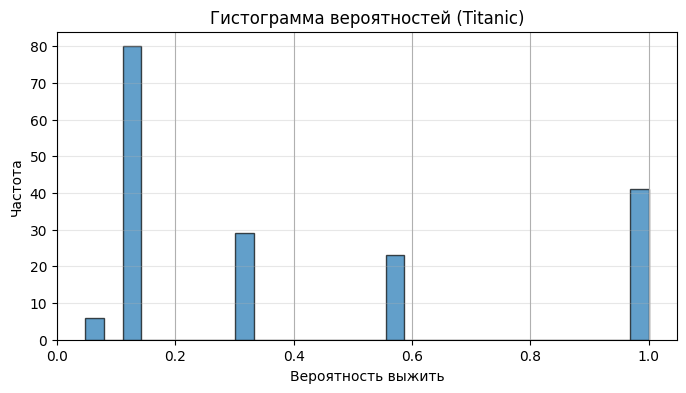

In [ ]:
# Ячейка 7: Гистограмма вероятностей
plt.figure(figsize=(8,4))
pd.Series(y_proba).hist(bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Вероятность выжить')
plt.ylabel('Частота')
plt.title('Гистограмма вероятностей (Titanic)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 📘 Изменение порога классификации и его влияние на precision

## 🧠 Зачем менять порог?

По умолчанию модели классификации (например, решающее дерево) относят объект к классу `1`, если предсказанная вероятность превышает **0.5**. Однако этот порог не всегда оптимален. В зависимости от бизнес-задачи мы можем:

- **Снизить порог** (например, до `0.3`) → модель чаще предсказывает положительный класс, что увеличивает **полноту (recall)**, но может снизить **точность (precision)**.
- **Повысить порог** (например, до `0.7`) → модель реже предсказывает положительный класс, что повышает **precision** (меньше ложных срабатываний), но может снизить **recall** (больше пропусков).

Меняя порог, мы управляем компромиссом между precision и recall.

## 🔍 Код для анализа precision при разных порогах

```python
# Массив вероятностей положительного класса (например, выжить)
y_proba = best_clf.predict_proba(X_test)[:, 1]

# Список порогов для проверки
thresholds = [0.3, 0.5, 0.7]
print("Precision при разных порогах:")
for th in thresholds:
    # Преобразуем вероятности в бинарные метки с новым порогом
    y_pred_th = (y_proba > th).astype(int)
    # Вычисляем precision
    prec = precision_score(y_test, y_pred_th)
    print(f"  Порог {th}: precision = {prec:.4f}")

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
# Ячейка 8: Precision при разных порогах


thresholds = [0.3, 0.5, 0.7]
print("Порог | Precision | Recall   | F1-score")
print("-" * 40)
for th in thresholds:
    y_pred_th = (y_proba > th).astype(int)
    prec = precision_score(y_test, y_pred_th)
    rec = recall_score(y_test, y_pred_th)
    f1 = f1_score(y_test, y_pred_th)
    print(f"{th:5.1f} | {prec:.4f}   | {rec:.4f}   | {f1:.4f}")




# 📊 Ожидаемые результаты (на примере Titanic)
# Порог 0.3 – модель более «смелая», часто предсказывает выживание. Вероятно, precision будет ниже, так как возрастает число ложных срабатываний (FP).

# Порог 0.5 – стандартное значение, precision около базового (например, 0.80).

# Порог 0.7 – модель осторожная, предсказывает выживание только при высокой уверенности. Precision обычно выше, но recall падает

Порог | Precision | Recall   | F1-score
----------------------------------------
  0.3 | 0.6882   | 0.8649   | 0.7665
  0.5 | 0.7969   | 0.6892   | 0.7391
  0.7 | 0.9024   | 0.5000   | 0.6435


# 📈 ROC-кривая и AUC: полный разбор

## 🎯 Что такое ROC-кривая?

**ROC (Receiver Operating Characteristic)** — это график, который показывает способность бинарного классификатора разделять два класса при изменении порога принятия решения.

- **По оси X** откладывается **False Positive Rate (FPR)** = FP / (FP + TN) — доля ложных срабатываний (специфичность = 1 – FPR).
- **По оси Y** откладывается **True Positive Rate (TPR)** = TP / (TP + FN) — чувствительность (recall).

Каждая точка на кривой соответствует определённому порогу вероятности (от 0 до 1). Чем ближе кривая к левому верхнему углу (0,1), тем лучше модель.

## 🧠 Зачем нужна ROC-кривая?

- Позволяет оценить качество классификации **независимо от выбранного порога**.
- Сравнивать разные модели по площади под кривой (AUC).
- Выбирать оптимальный порог, который максимизирует `TPR - FPR` (критерий Юдена).

## 🔍 Разбор кода

```python
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)

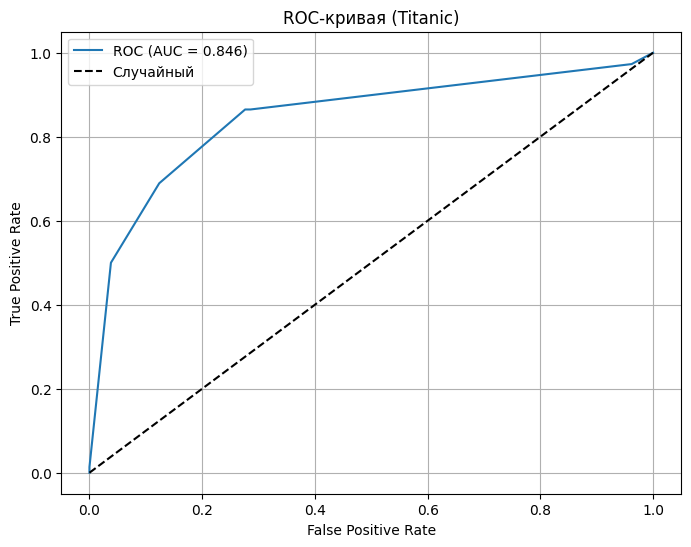

In [ ]:
# Ячейка 9: ROC-кривая
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'ROC (AUC = {auc:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Случайный')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая (Titanic)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Ячейка 10: Оптимальный порог
optimal_idx = np.argmax(tpr - fpr)
optimal_th = thresholds_roc[optimal_idx]
print(f"Оптимальный порог: {optimal_th:.3f}")
print(f"TPR = {tpr[optimal_idx]:.3f}, FPR = {fpr[optimal_idx]:.3f}")

Оптимальный порог: 0.330
TPR = 0.865, FPR = 0.276


# 🚀 Тема 2.7: Практика, Scikit-learn, fit, predict, you are awesome

## 🎯 Что мы будем делать?

Это практический блок, в котором вы научитесь применять модели машинного обучения из библиотеки `scikit-learn` на реальных данных.

In [ ]:
# Задание номер 1
import pandas as pd
from sklearn.tree import DecisionTreeClassifier

# 1. Загружаем данные
df = pd.read_csv('https://stepik.org/media/attachments/course/4852/train_data_tree.csv')

# 2. Подготавливаем признаки (X) и целевую переменную (y)
X = df[['sex', 'exang']]
y = df['num']

# 3. Создаем и обучаем Decision Tree классификатор
# Критерий 'entropy' (строчными буквами!) включает расчет Information Gain
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
model.fit(X, y)

# 4. Извлекаем важность признаков (Information Gain)
# model.feature_importances_ содержит нормализованное значение Information Gain для каждого признака
# Первый элемент соответствует 'sex', второй — 'exang'.
information_gains = model.feature_importances_

# Выводим результат для наглядности
print(f"Information Gain для признака 'sex':    {information_gains[0]:.3f}")
print(f"Information Gain для признака 'exang': {information_gains[1]:.3f}")

# 5. Выводим максимальное значение, которое и будет ответом в задании
print(f"\nМаксимальный нормализованный Information Gain: {max(information_gains):.3f}")

Information Gain для признака 'sex':    0.241
Information Gain для признака 'exang': 0.759

Максимальный Information Gain: 0.759


In [ ]:
# Задание номер 2
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# 1. Загружаем данные через sklearn
iris = load_iris()
X = iris.data          # признаки (numpy array)
y = iris.target        # целевая переменная (0,1,2)

# 2. Разделяем на обучающую (75%) и тестовую (25%) выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# 3. Создаём дерево решений с параметрами по умолчанию
dt = DecisionTreeClassifier()

# 4. Обучаем на тренировочных данных
dt.fit(X_train, y_train)

# 5. Предсказываем классы для тестовой выборки
predicted = dt.predict(X_test)

# (Необязательно) можно вывести точность для самопроверки
print(f"Точность: {dt.score(X_test, y_test):.4f}")




Точность: 1.0000


In [ ]:
# --- Предсказание для нового цветка ---
# Признаки в порядке: sepal length, sepal width, petal length, petal width
new_flower = [[5.1, 3.5, 1.4, 0.2]]   # типичный setosa
predicted_class = dt.predict(new_flower)[0]
print(f"Предсказанный вид: {iris.target_names[predicted_class]}")


# versicolor (примерно)
new_flower2 = [[6.0, 2.8, 4.5, 1.3]]
print(dt.predict(new_flower2)[0], iris.target_names[dt.predict(new_flower2)[0]])

# virginica (примерно)
new_flower3 = [[7.0, 3.0, 5.5, 2.0]]
print(dt.predict(new_flower3)[0], iris.target_names[dt.predict(new_flower3)[0]])

Предсказанный вид: setosa
1 versicolor
2 virginica


In [ ]:
# Задание номер 3
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import load_iris

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Сетка параметров
param_grid = {
    'max_depth': range(1, 11),          # от 1 до 10 (включительно)
    'min_samples_split': range(2, 11),  # от 2 до 10
    'min_samples_leaf': range(1, 11)    # от 1 до 10
}

# Создание GridSearchCV
search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
search.fit(X_train, y_train)

# Лучшее дерево
best_tree = search.best_estimator_


print("Лучшие параметры:", search.best_params_)
print("Лучшая точность на кросс-валидации:", search.best_score_)



Лучшие параметры: {'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2}
Лучшая точность на кросс-валидации: 0.9454545454545455


# 🔀 RandomizedSearchCV – случайный поиск гиперпараметров

## 🎯 Когда использовать?

- Когда **сетка параметров большая** (например, >10–20 значений на параметр).
- Когда полный перебор (`GridSearchCV`) занимает слишком много времени.
- Когда некоторые параметры могут быть не важны – случайный поиск часто даёт почти такие же результаты, но быстрее.

## 🧠 Как работает?

Из заданного пространства параметров случайным образом выбирается `n_iter` комбинаций (например, 50). Для каждой комбинации проводится кросс-валидация. Лучшая комбинация запоминается.

## 📌 Основные параметры

| Параметр | Назначение |
|----------|------------|
| `estimator` | Модель (например, `DecisionTreeClassifier()`) |
| `param_distributions` | Словарь с распределениями параметров (например, `{'max_depth': range(1, 30)}`) |
| `n_iter` | Количество случайных комбинаций (по умолчанию 10) |
| `cv` | Число фолдов кросс-валидации |
| `scoring` | Метрика (например, `'accuracy'`, `'roc_auc'`) |
| `random_state` | Для воспроизводимости |
| `n_jobs` | Количество параллельных процессов (-1 – все ядра) |

## 🧪 Пример (решающее дерево)

```python
from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier

param_dist = {
    'max_depth': range(1, 30),
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 10),
    'criterion': ['gini', 'entropy']
}

rand_search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                                 param_distributions=param_dist,
                                 n_iter=50,
                                 cv=5,
                                 scoring='accuracy',
                                 random_state=42,
                                 n_jobs=-1)
rand_search.fit(X_train, y_train)

best_tree = rand_search.best_estimator_
print(rand_search.best_params_)

In [ ]:
# Задание номер 4

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris

# Загрузка данных
iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)



param_dist = {
    'max_depth': range(1, 11),
    'min_samples_split': range(2, 11),
    'min_samples_leaf': range(1, 11)
}

search = RandomizedSearchCV(DecisionTreeClassifier(random_state=42),
                                 param_distributions=param_dist,
                                 n_iter=50,
                                 cv=5,
                                 scoring='accuracy',
                                 random_state=42,
                                 n_jobs=-1)
search.fit(X_train, y_train)

best_tree = search.best_estimator_
print(search.best_params_)
print(search.best_score_)

{'min_samples_split': 4, 'min_samples_leaf': 4, 'max_depth': 4}
0.9454545454545455


In [ ]:
# Задание номер 5 (не пытаяйся запустить код, он предназначен для демонстрации работы predict)
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split


train = pd.read_csv('train.csv')  # Пример загрузки, если данные в CSV
test = pd.read_csv('test.csv')


X_train = train.drop('y', axis=1)
y_train = train['y']

X_test = test

model = DecisionTreeClassifier()
# Сетка параметров
param_grid = {
    'max_depth': range(1, 11),          # от 1 до 10 (включительно)
    'min_samples_split': range(2, 11),  # от 2 до 10
    'min_samples_leaf': range(1, 11)    # от 1 до 10
}


search = GridSearchCV(estimator = model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
search.fit(X_train, y_train)


best_params = search.best_params_
best_tree = search.best_estimator_


predictions = search.predict(X_test)




# 🌳 Тема 3.1: Снова возвращаемся к деревьям

## 📌 Гиперпараметры решающего дерева и переобучение

Решающее дерево легко переобучается, если его не ограничивать. Основные параметры, которые влияют на переобучение:

| Параметр | Что делает | Влияние на переобучение |
|----------|------------|--------------------------|
| `max_depth` | Максимальная глубина дерева | **Чем меньше → тем меньше переобучение** |
| `min_samples_split` | Минимум объектов для разбиения узла | **Чем больше → тем меньше переобучение** |
| `min_samples_leaf` | Минимум объектов в листе | **Чем больше → тем меньше переобучение** |
| `min_impurity_decrease` | Минимальное улучшение чистоты для разбиения | **Чем больше → тем меньше переобучение** |

### ✅ Правильные утверждения (из задания):
- Малая глубина дерева препятствует переобучению
- Чем больше `min_samples_split`, тем меньше переобучение
- Уменьшение `min_samples_leaf` → **увеличивает** переобучение
- Увеличение `min_impurity_decrease` → **уменьшает** переобучение

---

## ⚙️ GridSearchCV vs RandomizedSearchCV

Оба инструмента нужны для **автоматического подбора гиперпараметров**.

### 🔍 GridSearchCV — полный перебор
- Перебирает **все** комбинации параметров из заданного списка
- ✅ **Плюс:** гарантирует лучший вариант среди перебранных
- ❌ **Минус:** очень медленный при большом количестве параметров

### 🎲 RandomizedSearchCV — случайный поиск
- Перебирает **случайные** комбинации (сколько укажешь)
- ✅ **Плюс:** быстрее, особенно при 5+ параметрах
- ❌ **Минус:** нет гарантии найти оптимальный вариант

### 🍕 Простая аналогия
Ты ищешь лучшую пиццерию в городе из 100 заведений:
- **GridSearchCV** → читаешь отзывы обо всех 100 (надёжно, но долго)
- **RandomizedSearchCV** → пробуешь 10 случайных (быстро, но можно пропустить идеал)

### 📋 Итог: когда что использовать?

| Ситуация | Рекомендация |
|----------|---------------|
| Параметров 2–4, время не критично | `GridSearchCV` |
| Параметров 5–10+, данных много | `RandomizedSearchCV` |
| Есть непрерывные параметры (0.1, 0.2, ...) | `RandomizedSearchCV` |
| Нужна воспроизводимость и точность | `GridSearchCV` |

---

## 🔧 Пример параметров для дерева

```python
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Всего комбинаций: 4 × 3 × 3 = 48

In [ ]:
# ============================================================
# Практический пример: GridSearchCV vs RandomizedSearchCV
# для DecisionTreeClassifier
# ============================================================

import numpy as np
import time
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

# Генерируем данные (1000 объектов, 10 признаков)
X, y = make_classification(n_samples=1000, n_features=10, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Базовая модель
tree = DecisionTreeClassifier(random_state=42)

# ------------------------------------------------------------
# 1. GridSearchCV - полный перебор
# ------------------------------------------------------------
print("=" * 60)
print("🔍 GridSearchCV - ПОЛНЫЙ ПЕРЕБОР")
print("=" * 60)

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

start = time.time()
grid_search = GridSearchCV(tree, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)
grid_time = time.time() - start

print(f"📊 Всего комбинаций: {grid_search.param_grid['max_depth'] * len(grid_search.param_grid['min_samples_split']) * len(grid_search.param_grid['min_samples_leaf'])}")
print(f"✅ Лучшие параметры: {grid_search.best_params_}")
print(f"✅ Лучшая точность (CV): {grid_search.best_score_:.4f}")
print(f"⏱️ Время выполнения: {grid_time:.2f} сек")
print(f"🎯 Точность на тесте: {grid_search.score(X_test, y_test):.4f}")

# ------------------------------------------------------------
# 2. RandomizedSearchCV - случайный поиск
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("🎲 RandomizedSearchCV - СЛУЧАЙНЫЙ ПОИСК")
print("=" * 60)

param_dist = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

start = time.time()
random_search = RandomizedSearchCV(tree, param_dist, n_iter=10, cv=3,
                                   scoring='accuracy', random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)
random_time = time.time() - start

total_combinations = len(param_dist['max_depth']) * len(param_dist['min_samples_split']) * len(param_dist['min_samples_leaf'])

print(f"📊 Всего возможно комбинаций: {total_combinations}")
print(f"🎲 Проверено случайно: 10 (n_iter=10)")
print(f"✅ Лучшие параметры: {random_search.best_params_}")
print(f"✅ Лучшая точность (CV): {random_search.best_score_:.4f}")
print(f"⏱️ Время выполнения: {random_time:.2f} сек")
print(f"🎯 Точность на тесте: {random_search.score(X_test, y_test):.4f}")

# ------------------------------------------------------------
# 3. Сравнение
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("📊 СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("=" * 60)

print(f"GridSearchCV:      {grid_time:.2f} сек | Точность: {grid_search.score(X_test, y_test):.4f}")
print(f"RandomizedSearchCV: {random_time:.2f} сек | Точность: {random_search.score(X_test, y_test):.4f}")
print(f"\n💡 RandomizedSearchCV быстрее в {grid_time/random_time:.1f} раз!")

# ------------------------------------------------------------
# 4. Краткие выводы для деревьев
# ------------------------------------------------------------
print("\n" + "=" * 60)
print("📌 КЛЮЧЕВЫЕ ВЫВОДЫ ДЛЯ ДЕРЕВЬЕВ")
print("=" * 60)
print("✅ Малая глубина (max_depth) → препятствует переобучению")
print("✅ Большое min_samples_split → снижает переобучение")
print("✅ Меньшее min_samples_leaf → УВЕЛИЧИВАЕТ переобучение")
print("✅ Большее min_impurity_decrease → УМЕНЬШАЕТ переобучение")
print("\n⚙️ По подбору параметров:")
print("   → Параметров мало (2-4): используй GridSearchCV")
print("   → Параметров много (5-10+): используй RandomizedSearchCV")

🔍 GridSearchCV - ПОЛНЫЙ ПЕРЕБОР
📊 Всего комбинаций: [3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10, 3, 5, 7, 10]
✅ Лучшие параметры: {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 5}
✅ Лучшая точность (CV): 0.9125
⏱️ Время выполнения: 10.25 сек
🎯 Точность на тесте: 0.8550

🎲 RandomizedSearchCV - СЛУЧАЙНЫЙ ПОИСК
📊 Всего возможно комбинаций: 36
🎲 Проверено случайно: 10 (n_iter=10)
✅ Лучшие параметры: {'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 5}
✅ Лучшая точность (CV): 0.9075
⏱️ Время выполнения: 0.35 сек
🎯 Точность на тесте: 0.8500

📊 СРАВНЕНИЕ РЕЗУЛЬТАТОВ
GridSearchCV:      10.25 сек | Точность: 0.8550
RandomizedSearchCV: 0.35 сек | Точность: 0.8500

💡 RandomizedSearchCV быстрее в 29.5 раз!

📌 КЛЮЧЕВЫЕ ВЫВОДЫ ДЛЯ ДЕРЕВЬЕВ
✅ Малая глубина (max_depth) → препятствует переобучению
✅ Большое min_samples_split → снижает переобучение
✅ Меньшее min_samples_leaf → УВЕЛИЧИВАЕТ переобучение
✅ Большее min_impu

# 🚀 Практикум: Деревья решений и подбор гиперпараметров

## Повторение ключевых тем:
- Разделение данных на train/test
- Создание модели DecisionTreeClassifier
- GridSearchCV vs RandomizedSearchCV
- Анализ параметров для тюнинга

**Девиз:** "Понимаю → Пробую → Закрепляю"

---

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np


wine = load_wine()
# wine.target
# wine.data
# wine.feature_names
# wine.target_names
# wine.DESCR
# wine.frame


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2])

# 📘 Краткий справочник: sklearn Bunch и pandas DataFrame

## 1️⃣ Объект wine (Bunch) — что внутри?

| Ключ | Что хранит | Как достать |
|------|-----------|-------------|
| `data` | Числовые признаки (X) | `wine.data` |
| `target` | Целевые метки (y) | `wine.target` |
| `feature_names` | Названия признаков | `wine.feature_names` |
| `target_names` | Названия классов | `wine.target_names` |
| `DESCR` | Описание датасета | `wine.DESCR` |
| `frame` | Таблица (DataFrame) | `wine.frame` |

## 2️⃣ Индексация списков (квадратные скобки)

```python
список = ['a', 'b', 'c']
список[0]  # 'a'  (первый)
список[1]  # 'b'  (второй)
список[2]  # 'c'  (третий)
# СЧЁТ НАЧИНАЕТСЯ С НУЛЯ!

In [ ]:
# Создание DataFrame из wine

import pandas as pd

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target                    # добавить колонку с числами
df['target_name'] = df['target'].map({0: 'класс0', 1: 'класс1', 2: 'класс2'})

df.head(15)

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,target_name
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,класс0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,класс0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,класс0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,класс0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,класс0
5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,0,класс0
6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,0,класс0
7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,0,класс0
8,14.83,1.64,2.17,14.0,97.0,2.80,2.98,0.29,1.98,5.20,1.08,2.85,1045.0,0,класс0
9,13.86,1.35,2.27,16.0,98.0,2.98,3.15,0.22,1.85,7.22,1.01,3.55,1045.0,0,класс0


In [ ]:
# 🎯 Золотое правило
# Если хочешь таблицу → сделай DataFrame:


df = pd.DataFrame(wine.data, columns=wine.feature_names)
df.head()  # работает!




,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [ ]:
# Если хочешь просто данные для модели → бери из wine:
X = wine.data    # признаки
y = wine.target  # метки
# print(X)

[[1.423e+01 1.710e+00 2.430e+00 ... 1.040e+00 3.920e+00 1.065e+03]
 [1.320e+01 1.780e+00 2.140e+00 ... 1.050e+00 3.400e+00 1.050e+03]
 [1.316e+01 2.360e+00 2.670e+00 ... 1.030e+00 3.170e+00 1.185e+03]
 ...
 [1.327e+01 4.280e+00 2.260e+00 ... 5.900e-01 1.560e+00 8.350e+02]
 [1.317e+01 2.590e+00 2.370e+00 ... 6.000e-01 1.620e+00 8.400e+02]
 [1.413e+01 4.100e+00 2.740e+00 ... 6.100e-01 1.600e+00 5.600e+02]]


In [ ]:
# .map() — замена значений
# Было: [0, 1, 0, 2, 1]
df['target'].map({0: 'вино А', 1: 'вино Б', 2: 'вино В'})
# Стало: ['вино А', 'вино Б', 'вино А', 'вино В', 'вино Б']

,target
0,вино А
1,вино А
2,вино А
3,вино А
4,вино А
...,...
173,вино В
174,вино В
175,вино В
176,вино В


In [ ]:
# ============================================================
# ПОЛНЫЙ ПРИМЕР: Дерево решений + GridSearchCV + RandomizedSearchCV
# Датасет: Wine (классификация вин)
# ============================================================

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import pandas as pd
import time

# ============================================================
# 1. ЗАГРУЗКА ДАННЫХ И РАЗДЕЛЕНИЕ
# ============================================================
print("=" * 70)
print("📊 ШАГ 1: Загрузка данных и разделение на train/test")
print("=" * 70)

# Загружаем датасет Wine
wine = load_wine()

X = wine.data
y= wine.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42,
                                                    stratify=y ) # сохраняем пропорции классов


print(f"Размер X_train: {X_train.shape}")
print(f"Размер X_test: {X_test.shape}")
print(f"Размер y_train: {y_train.shape}")
print(f"Размер y_test: {y_test.shape}")








📊 ШАГ 1: Загрузка данных и разделение на train/test
Размер X_train: (124, 13)
Размер X_test: (54, 13)
Размер y_train: (124,)
Размер y_test: (54,)


In [ ]:
# ============================================================
# 2. СОЗДАЁМ И ОБУЧАЕМ БАЗОВОЕ ДЕРЕВО
# ============================================================
print("\n" + "=" * 70)
print("🌳 ШАГ 2: Создаём и обучаем дерево решений (без тюнинга)")
print("=" * 70)


base_tree = DecisionTreeClassifier(random_state = 42)
base_tree.fit(X_train,y_train)


y_pred_base = base_tree.predict(X_test)

# Считаем точность
base_accuracy = accuracy_score(y_test, y_pred_base)

print(f"✅ Точность базового дерева: {base_accuracy:.4f} ({base_accuracy * 100:.2f}%)")
print("\n📋 Отчёт о классификации:")
print(classification_report(y_test, y_pred_base, target_names=wine.target_names))



🌳 ШАГ 2: Создаём и обучаем дерево решений (без тюнинга)
✅ Точность базового дерева: 0.9630 (96.30%)

📋 Отчёт о классификации:
              precision    recall  f1-score   support

     class_0       1.00      0.94      0.97        18
     class_1       0.91      1.00      0.95        21
     class_2       1.00      0.93      0.97        15

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.97      0.96      0.96        54



In [ ]:
# ============================================================
# 3. GridSearchCV - ПОЛНЫЙ ПЕРЕБОР
# ============================================================
print("\n" + "=" * 70)
print("🔍 ШАГ 3: GridSearchCV - полный перебор параметров")
print("=" * 70)


# Задаём сетку параметров
param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}


clf = DecisionTreeClassifier(random_state=42)
grid_search = GridSearchCV(clf, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)

start_time = time.time()
grid_search.fit(X_train, y_train)
grid_time = time.time() - start_time

print("\nЛучшие параметры (GridSearchCV):", grid_search.best_params_)
print(f"Лучшая средняя точность на кросс-валидации: {grid_search.best_score_:.4f}")
print(f"⏱️ Время выполнения: {grid_time:.2f} сек")


y_pred_grid = grid_search.predict(X_test)
grid_accuracy = accuracy_score(y_test, y_pred_grid)
print(f"✅ Точность на тесте: {grid_accuracy:.4f}")


🔍 ШАГ 3: GridSearchCV - полный перебор параметров
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Лучшие параметры (GridSearchCV): {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 5}
Лучшая средняя точность на кросс-валидации: 0.8780
⏱️ Время выполнения: 0.51 сек
✅ Точность на тесте: 0.9630


In [ ]:
# ============================================================
# 4. RandomizedSearchCV - СЛУЧАЙНЫЙ ПОИСК
# ============================================================
print("\n" + "=" * 70)
print("🎲 ШАГ 4: RandomizedSearchCV - случайный поиск")
print("=" * 70)

# Те же параметры, но будем брать случайные комбинации

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}



clf = DecisionTreeClassifier(random_state=42)
random_search = RandomizedSearchCV(clf,
    param_grid,
    n_iter=10,             # проверим только 10 случайных комбинаций
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search.fit(X_train, y_train)
random_time = time.time() - start_time

print(f"✅ Лучшие параметры (RandomizedSearchCV): {random_search.best_params_}")
print(f"✅ Лучшая точность (CV): {random_search.best_score_:.4f}")
print(f"⏱️ Время выполнения: {random_time:.2f} сек")



y_pred_random = grid_search.predict(X_test)
random_accuracy = accuracy_score(y_test, y_pred_random)
print(f"✅ Точность на тесте: {random_accuracy:.4f}")


🎲 ШАГ 4: RandomizedSearchCV - случайный поиск
✅ Лучшие параметры (RandomizedSearchCV): {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
✅ Лучшая точность (CV): 0.8780
⏱️ Время выполнения: 0.15 сек
✅ Точность на тесте: 0.9630


In [ ]:
# ============================================================
# 5. СРАВНЕНИЕ РЕЗУЛЬТАТОВ
# ============================================================
print("\n" + "=" * 70)
print("📊 ШАГ 5: Сравнение всех моделей")
print("=" * 70)

print("\n┌─────────────┬────────────┬──────────────┬────────────┐")
print("│ Модель      │ Время (сек)│ Точность (CV)│ Тест       │")
print("├─────────────┼────────────┼──────────────┼────────────┤")
print(f"│ Базовое     │ -          │ -            │ {base_accuracy:.4f}     │")
print(f"│ GridSearch  │ {grid_time:.2f}       │ {grid_search.best_score_:.4f}      │ {grid_accuracy:.4f}     │")
print(f"│ Randomized  │ {random_time:.2f}       │ {random_search.best_score_:.4f}      │ {random_accuracy:.4f}     │")
print("└─────────────┴────────────┴──────────────┴────────────┘")

print(f"\n💡 RandomizedSearchCV быстрее GridSearchCV в {grid_time/random_time:.1f} раз!")


📊 ШАГ 5: Сравнение всех моделей

┌─────────────┬────────────┬──────────────┬────────────┐
│ Модель      │ Время (сек)│ Точность (CV)│ Тест       │
├─────────────┼────────────┼──────────────┼────────────┤
│ Базовое     │ -          │ -            │ 0.9630     │
│ GridSearch  │ 0.51       │ 0.8780      │ 0.9630     │
│ Randomized  │ 0.15       │ 0.8780      │ 0.9630     │
└─────────────┴────────────┴──────────────┴────────────┘

💡 RandomizedSearchCV быстрее GridSearchCV в 3.4 раз!


In [ ]:
# ============================================================
# 6. ВЫВОДЫ
# ============================================================
print("\n" + "=" * 70)
print("📌 ИТОГОВЫЕ ВЫВОДЫ")
print("=" * 70)
print("""
✅ GridSearchCV:
   - Перебирает ВСЕ комбинации параметров
   - Гарантирует лучший результат среди заданных
   - НО: медленный при большом количестве параметров

✅ RandomizedSearchCV:
   - Перебирает случайные комбинации
   - Быстрее, особенно при 5+ параметрах
   - НО: нет гарантии найти оптимальный вариант

🎯 Рекомендация:
   - Параметров мало (2-4) → используй GridSearchCV
   - Параметров много (5-10+) → используй RandomizedSearchCV
""")


📌 ИТОГОВЫЕ ВЫВОДЫ

✅ GridSearchCV:
   - Перебирает ВСЕ комбинации параметров
   - Гарантирует лучший результат среди заданных
   - НО: медленный при большом количестве параметров

✅ RandomizedSearchCV:
   - Перебирает случайные комбинации
   - Быстрее, особенно при 5+ параметрах
   - НО: нет гарантии найти оптимальный вариант

🎯 Рекомендация:
   - Параметров мало (2-4) → используй GridSearchCV
   - Параметров много (5-10+) → используй RandomizedSearchCV



# 🌲 Тема 3.2: Random Forest (Случайный лес)

## 📌 Что такое Random Forest?

**Random Forest** — это ансамблевый метод машинного обучения, который строит **множество решающих деревьев** и объединяет их предсказания.

### Простая аналогия:
- **Одно дерево** = один эксперт. Он может ошибаться.
- **Случайный лес** = 100 экспертов. Каждый смотрит на проблему со своей стороны, а потом они голосуют. **Коллективное мнение точнее!**

---

## 🎯 Как работает Random Forest?

### Шаг 1. Создаём много деревьев
Random Forest строит не одно дерево, а целый лес — например, 100 или 500 деревьев.

### Шаг 2. Каждое дерево учится по-своему
Для каждого дерева алгоритм делает две вещи:

**А) Bootstrap (выборка с возвращением)**
- Из исходных данных случайно выбираются объекты
- Некоторые объекты могут попасть несколько раз
- Некоторые объекты не попадут вообще (это называется OOB — out-of-bag)

**Б) Random subspace (случайные признаки)**
- Каждому дереву даётся не весь набор признаков, а только их случайная часть
- Например, из 10 признаков каждое дерево видит только 3 случайных

### Шаг 3. Каждое дерево даёт свой ответ
Когда нужно предсказать ответ для нового объекта:
- Все деревья по очереди делают предсказание
- Каждое дерево "голосует" за свой класс

### Шаг 4. Лес принимает решение
- Для **классификации**: побеждает класс, за который проголосовало больше деревьев
- Для **регрессии**: берётся среднее арифметическое всех предсказаний

### Простая аналогия:
Один эксперт может ошибаться. Но если собрать 100 экспертов, дать каждому разный набор информации и спросить их мнение — коллективный ответ почти всегда будет правильным.


In [ ]:
## 🎯 Как работает Random Forest? (схема)

# ┌─────────────────────────────────────────────────────────────────┐
# │                     ИСХОДНЫЕ ДАННЫЕ                             │
# │                  (1000 объектов, 10 признаков)                  │
# └─────────────────────────────┬───────────────────────────────────┘
                              # │
        # ┌─────────────────────┼─────────────────────┐
        # │                     │                     │
        # ▼                     ▼                     ▼
# ┌───────────────┐     ┌───────────────┐     ┌───────────────┐
# │   BOOTSTRAP   │     │   BOOTSTRAP   │     │   BOOTSTRAP   │
# │ ───────────── │     │ ───────────── │     │ ───────────── │
# │ Случайная     │     │ Случайная     │     │ Случайная     │
# │ выборка       │     │ выборка       │     │ выборка       │
# │ из данных     │     │ из данных     │     │ из данных     │
# └───────┬───────┘     └───────┬───────┘     └───────┬───────┘
        # │                     │                     │
        # ▼                     ▼                     ▼
# ┌───────────────┐     ┌───────────────┐     ┌───────────────┐
# │ RANDOM        │     │ RANDOM        │     │ RANDOM        │
# │ SUBSPACE      │     │ SUBSPACE      │     │ SUBSPACE      │
# │ ───────────── │     │ ───────────── │     │ ───────────── │
# │ Случайные     │     │ Случайные     │     │ Случайные     │
# │ 3 признака    │     │ 3 признака    │     │ 3 признака    │
# │ из 10         │     │ из 10         │     │ из 10         │
# └───────┬───────┘     └───────┬───────┘     └───────┬───────┘
        # │                     │                     │
        # ▼                     ▼                     ▼
# ┌───────────────┐     ┌───────────────┐     ┌───────────────┐
# │   ДЕРЕВО 1    │     │   ДЕРЕВО 2    │     │   ДЕРЕВО N    │
# │               │     │               │     │               │
# │   говорит:    │     │   говорит:    │     │   говорит:    │
# │    "КЛАСС 0"  │     │    "КЛАСС 1"  │     │    "КЛАСС 0"  │
# └───────┬───────┘     └───────┬───────┘     └───────┬───────┘
        # │                     │                     │
        # └─────────────────────┼─────────────────────┘
                              # │
                              # ▼
              # ┌───────────────────────────┐
              # │       ГОЛОСОВАНИЕ         │
              # │   ────────────────────    │
              # │   Класс 0: 70 голосов     │
              # │   Класс 1: 25 голосов     │
              # │   Класс 2: 5 голосов      │
              # └─────────────┬─────────────┘
                            # │
                            # ▼
              # ┌───────────────────────────┐
              # │      ФИНАЛЬНЫЙ ОТВЕТ      │
              # │     → КЛАСС 0 ←           │
              # └───────────────────────────┘

In [ ]:
# ============================================
# СОЗДАЁМ ТАБЛИЦУ ДЛЯ ДАТАСЕТА DIGITS
# ============================================

from sklearn.datasets import load_digits
import pandas as pd
import numpy as np

# Загружаем данные
digits = load_digits()
X = digits.data
y = digits.target

# ============================================
# 1. ОСНОВНАЯ ТАБЛИЦА (первые 10 строк)
# ============================================

# Создаём DataFrame с признаками
# Имена колонок: pixel_0, pixel_1, ..., pixel_63 (всего 64 пикселя)
column_names = [f'pixel_{i}' for i in range(64)]
df = pd.DataFrame(X, columns=column_names)

# Добавляем колонку с целевой переменной (какая цифра)
df['digit'] = y

print("=" * 70)
print("📊 ТАБЛИЦА 1: Первые 10 строк датасета Digits")
print("=" * 70)
print("(Показаны первые 10 пикселей из 64, чтобы таблица помещалась)")
print()

# Показываем первые 10 строк, но только первые 10 пикселей + колонку digit
df_display = df.iloc[:10, :10]  # первые 10 строк, первые 10 колонок
df_display['digit'] = df['digit'][:10]  # добавляем колонку с цифрой

print(df_display.to_string())
print("\n... и так далее (всего 1797 строк, 64 пикселя)")

📊 ТАБЛИЦА 1: Первые 10 строк датасета Digits
(Показаны первые 10 пикселей из 64, чтобы таблица помещалась)

   pixel_0  pixel_1  pixel_2  pixel_3  pixel_4  pixel_5  pixel_6  pixel_7  pixel_8  pixel_9  digit
0      0.0      0.0      5.0     13.0      9.0      1.0      0.0      0.0      0.0      0.0      0
1      0.0      0.0      0.0     12.0     13.0      5.0      0.0      0.0      0.0      0.0      1
2      0.0      0.0      0.0      4.0     15.0     12.0      0.0      0.0      0.0      0.0      2
3      0.0      0.0      7.0     15.0     13.0      1.0      0.0      0.0      0.0      8.0      3
4      0.0      0.0      0.0      1.0     11.0      0.0      0.0      0.0      0.0      0.0      4
5      0.0      0.0     12.0     10.0      0.0      0.0      0.0      0.0      0.0      0.0      5
6      0.0      0.0      0.0     12.0     13.0      0.0      0.0      0.0      0.0      0.0      6
7      0.0      0.0      7.0      8.0     13.0     16.0     15.0      1.0      0.0      0.0      7
8

In [ ]:
# ============================================
# ПРОСТОЙ ПРИМЕР: Дерево решений на Digits
# ============================================

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import numpy as np
# 1. Загружаем данные
digits = load_digits()
X = digits.data
y = digits.target

print("=" * 50)
print("Датасет DIGITS")
print("=" * 50)
print(f"Количество изображений: {X.shape[0]}")
print(f"Количество пикселей в каждом: {X.shape[1]}")
print(f"Цифры: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")
print(f"Распределение: {dict(zip(*np.unique(y, return_counts=True)))}")

# 2. Делим на train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape[0]} изображений")
print(f"Тестовая выборка: {X_test.shape[0]} изображений")

# 3. Создаём и обучаем дерево
tree = DecisionTreeClassifier(random_state=42)
tree.fit(X_train, y_train)

print("\n✅ Модель обучена!")

# 4. Предсказываем на тестовых данных
y_pred = tree.predict(X_test)

# 5. Считаем точность
acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Точность на тесте: {acc:.4f} ({acc * 100:.2f}%)")

Датасет DIGITS
Количество изображений: 1797
Количество пикселей в каждом: 64
Цифры: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9
Распределение: {np.int64(0): np.int64(178), np.int64(1): np.int64(182), np.int64(2): np.int64(177), np.int64(3): np.int64(183), np.int64(4): np.int64(181), np.int64(5): np.int64(182), np.int64(6): np.int64(181), np.int64(7): np.int64(179), np.int64(8): np.int64(174), np.int64(9): np.int64(180)}

Обучающая выборка: 1437 изображений
Тестовая выборка: 360 изображений

✅ Модель обучена!

📊 Точность на тесте: 0.8417 (84.17%)


In [ ]:
# ============================================
# ПРОСТОЙ ПРИМЕР: Random Forest на Digits
# ============================================

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np

# 1. Загружаем данные
digits = load_digits()
X = digits.data
y = digits.target

print("=" * 50)
print("Датасет DIGITS")
print("=" * 50)
print(f"Количество изображений: {X.shape[0]}")
print(f"Количество пикселей в каждом: {X.shape[1]}")
print(f"Цифры: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9")

# 2. Делим на train/test (80% / 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\nОбучающая выборка: {X_train.shape[0]} изображений")
print(f"Тестовая выборка: {X_test.shape[0]} изображений")

# 3. СОЗДАЁМ И ОБУЧАЕМ RANDOM FOREST
#    n_estimators = количество деревьев в лесу
rf = RandomForestClassifier(n_estimators=100, random_state=42)

print("\n🌲 Обучаем Random Forest из 100 деревьев...")
rf.fit(X_train, y_train)

print("✅ Модель обучена!")

# 4. Предсказываем на тестовых данных
y_pred = rf.predict(X_test)

# 5. Считаем точность
acc = accuracy_score(y_test, y_pred)

print(f"\n📊 Точность на тесте: {acc:.4f} ({acc * 100:.2f}%)")

Датасет DIGITS
Количество изображений: 1797
Количество пикселей в каждом: 64
Цифры: 0, 1, 2, 3, 4, 5, 6, 7, 8, 9

Обучающая выборка: 1437 изображений
Тестовая выборка: 360 изображений

🌲 Обучаем Random Forest из 100 деревьев...
✅ Модель обучена!

📊 Точность на тесте: 0.9722 (97.22%)


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving heart-disease.csv to heart-disease.csv


In [ ]:
import pandas as pd
heart_df = pd.read_csv('heart-disease.csv')
heart_df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


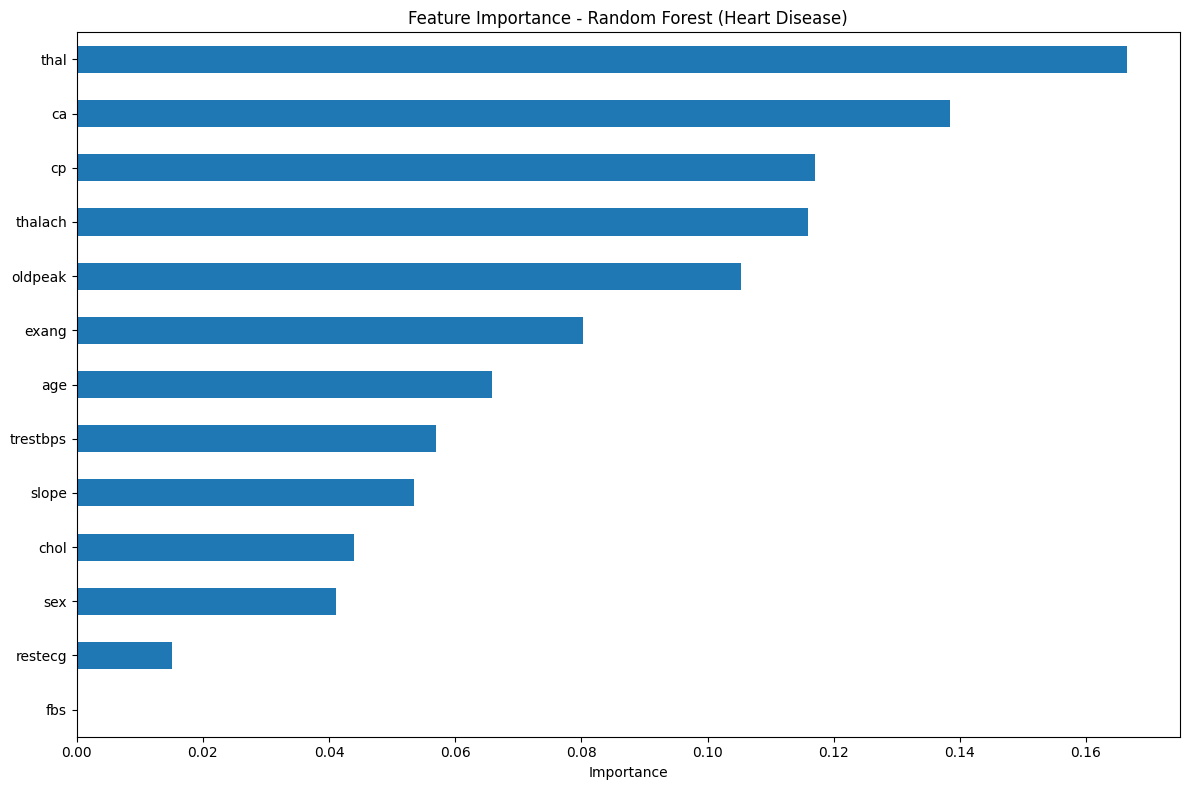

Важность признаков:
----------------------------------------
age             : 0.0658
sex             : 0.0412
cp              : 0.1170
trestbps        : 0.0569
chol            : 0.0440
fbs             : 0.0000
restecg         : 0.0151
thalach         : 0.1160
exang           : 0.0803
oldpeak         : 0.1053
slope           : 0.0535
ca              : 0.1384
thal            : 0.1666


In [ ]:
# Воспользуемся данными о сердечных заболеваниях и обучим на них Random Forest.
# Постройте график важности переменных для классификации и выберите среди предложенных вариантов наиболее похожий.
# В задании присутствует рандом, прогоните обучение случайного леса и построение графика несколько раз,
# Воспользуемся данными о сердечных заболеваниях и обучим на них Random Forest.
# Постройте график важности переменных для классификации и выберите среди предложенных вариантов наиболее похожий.
# В задании присутствует рандом, прогоните обучение случайного леса и построение графика несколько раз, чтобы увидеть изменения в важности фичей (5 самых важных обычно присутствуют в топе, просто в разном порядке).
# чтобы увидеть изменения в важности фичей (5 самых важных обычно присутствуют в топе, просто в разном порядке).

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

heart_df = pd.read_csv('heart-disease.csv')
heart_df.head()

X = heart_df.drop('target', axis = 1)
y = heart_df['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



# Фиксируем random_state как в задании
np.random.seed(0)

# Обучаем Random Forest НА ТРЕНИРОВОЧНЫХ данных
rf = RandomForestClassifier(n_estimators=10, max_depth=5)
rf.fit(X_train, y_train)  # ← обучаем на X_train!

#  Создаём DataFrame с важностью признаков
#    Используем X_train.columns (как в задании на скриншоте)
importance_df = pd.DataFrame(
    rf.feature_importances_,
    index=X_train.columns,  # ← вот здесь используют x_train.columns
    columns=['importance']
)

#  Сортируем и выводим
importance_df = importance_df.sort_values('importance', ascending=True)

# Рисуем график
importance_df.plot(kind='barh', figsize=(12, 8), legend=False)
plt.xlabel('Importance')
plt.title('Feature Importance - Random Forest (Heart Disease)')
plt.tight_layout()
plt.show()







importances = rf.feature_importances_
feature_names = X.columns

print("Важность признаков:")
print("-" * 40)
for name, importance in zip(feature_names, importances):
    print(f"{name:15} : {importance:.4f}")


In [ ]:
import pandas as pd

# Создаём DataFrame и сортируем
importance_df = pd.DataFrame({
    'Признак': feature_names,
    'Важность': importances
}).sort_values('Важность', ascending=False)

print("Важность признаков (от самого важного):")
print(importance_df)

Важность признаков (от самого важного):
     Признак  Важность
12      thal  0.166568
11        ca  0.138407
2         cp  0.117017
7    thalach  0.115988
9    oldpeak  0.105320
8      exang  0.080296
0        age  0.065761
3   trestbps  0.056896
10     slope  0.053520
4       chol  0.043972
1        sex  0.041152
6    restecg  0.015102
5        fbs  0.000000


# 🌲 Тема 3.3: Зачем знать что-то ещё, если есть Random Forest?

Random Forest — мощный алгоритм, который часто отлично работает «из коробки». Однако он не является серебряной пулей. В этом уроке разбирается, почему специалисту по Data Science важно знать и другие методы.

## 1. 🎯 Короткий ответ: универсальность VS контекст

> **«Если у вас есть молоток, всё вокруг похоже на гвоздь».**

Random Forest — отличный «молоток», но в реальных задачах требования бывают разными:
*   Нужна не просто точность, а **скорость** работы модели.
*   Важна не предсказательная сила, а **прозрачность** решения.
*   Данные могут быть **специфического типа** (тексты, временные ряды).

## 2. ⚠️ Основные ограничения Random Forest (Почему он не всегда подходит)

### А) Отсутствие интерпретируемости («Черный ящик»)
В отличие от одного дерева решений, лес из 100 деревьев невозможно «посмотреть» или нарисовать.
*   **Проблема:** В медицине, банковском скоринге или судебной системе нужно объяснить, **почему** модель приняла такое решение [citation:3][citation:8].
*   **Альтернатива:** Логистическая регрессия или *одно* неглубокое дерево решений.

### Б) Медленное предсказание (Inference)
*   **Проблема:** Чтобы предсказать один результат, нужно прогнать данные через сотни деревьев и усреднить ответ. Это долго.
*   **Следствие:** RF плохо подходит для **real-time** систем (например, мгновенная блокировка транзакции или управление беспилотником), где критична каждая миллисекунда [citation:9].

### В) Склонность к переобучению на шумных данных
*   **Парадокс:** Хотя Random Forest устойчив к переобучению, **при недостаточной настройке** (особенно при большом количестве деревьев без ограничения глубины) он может начать запоминать шум [citation:6].
*   **Почему:** Если `max_depth` слишком большая, деревья становятся слишком сложными.

## 3. 🧠 Особые типы данных: когда RF проигрывает

### А) Разреженные данные (Sparse / High-Dimensional)
*   **Пример:** Классификация текстов (Bow, TF-IDF). У нас тысячи слов (признаков), но в одном документе их всего 100.
*   **Почему RF плох:** Деревья ищут разбиения в «пустоте». Огромное количество нулей мешает алгоритму находить полезные признаки [citation:4].
*   **Что лучше:** **Линейные модели** (Logistic Regression с L1-регуляризацией) или **SVM**.

### Б) Данные с неявными связями (Изображения, Сигналы)
*   **Проблема:** RF работает с «плоскими» таблицами, где каждый столбец это конкретный признак.
*   **Задача:** Распознать кошку на фото. Соседние пиксели образуют форму, а RF не умеет автоматически находить эти пространственные зависимости.
*   **Что лучше:** **Сверточные нейронные сети (CNN)** [citation:9].

## 4. ⚔️ Зачем нужны другие алгоритмы? (Сравнение)

| Алгоритм | Сравнение с Random Forest | Когда он побеждает |
| :--- | :--- | :--- |
| **Линейная регрессия / Логистическая регрессия** | RF ловит сложные нелинейные связи. | Когда важна **скорость** и **простота**. Если связь признаков и целевой переменной линейна, простая модель не уступит в точности, но будет мгновенной [citation:3]. |
| **Градиентный бустинг (XGBoost, LightGBM, CatBoost)** | RF строит деревья независимо (Bagging). Бустинг строит деревья последовательно, каждое исправляет ошибки предыдущего. | В **соревнованиях** (Kaggle) и задачах с **очень большими табличными данными**. Бустинг почти всегда дает более высокую точность, хотя требует больше настроек [citation:8][citation:9]. |
| **SVM (Метод опорных векторов)** | RF усредняет. SVM ищет идеальную разделяющую плоскость. | Если данных **мало**, но они хорошо структурированы, SVM может дать уникальный результат там, где лес «размышляет» [citation:5]. |
| **Нейронные сети (Deep Learning)** | RF — это деревья. | Для **неструктурированных данных** (изображения, звук, видео, сложный текст). Нейронки сами извлекают признаки [citation:3][citation:9]. |

## 5. 📝 Вывод по уроку

Знать только Random Forest — это как уметь готовить только яичницу. Она вкусная и простая, но...

1.  **Для бизнеса:** Часто важнее **объяснить** решение, чем получить 100% точность. Тут нужна простая регрессия.
2.  **Для скорости:** Для миллионов клиентов предсказание должно проходить за доли секунды. Бустинг (LightGBM) часто справляется быстрее классического RF.
3.  **Для сложных данных:** Тексты и картинки — территория нейросетей.

**Главная мысль:** Data Scientist — это не «специалист по Random Forest», а инженер, который умеет подбирать инструмент под задачу. RF — мощный инструмент в вашем арсенале, но он не единственный.




# 🍎 Тема 3.5: И на Марсе будут яблони цвести...

In [ ]:
# Задание 1

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving training_mush.csv to training_mush.csv


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd


mashrooms_df = pd.read_csv('training_mush.csv')
mashrooms_df.head()

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat,class
0,2,0,3,1,5,1,0,0,9,1,...,3,7,0,2,1,4,3,5,0,0
1,2,0,4,0,5,1,0,1,10,0,...,7,4,0,2,1,0,7,4,0,1
2,2,0,3,0,2,1,0,0,7,0,...,0,4,0,2,1,2,1,5,1,1
3,0,0,3,0,5,1,1,0,2,0,...,7,7,0,2,2,4,7,3,1,0
4,2,3,3,1,5,1,0,0,10,1,...,3,6,0,2,1,4,2,5,0,0


In [ ]:
X = mashrooms_df.drop('class', axis = 1)
y = mashrooms_df['class']


In [ ]:
params = {
    'n_estimators': [10, 20, 30, 40, 50],
    'max_depth': [1, 3, 5, 7, 9, 11],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7],
    'min_samples_split': [2, 4, 6, 8]
}




rf = RandomForestClassifier(random_state=0)

grid_search = GridSearchCV(rf, params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X, y)

best_params = grid_search.best_params_
best_rf = grid_search.best_estimator_

print(f'Лучшие параметры: {best_params}')

Fitting 3 folds for each of 840 candidates, totalling 2520 fits
Лучшие параметры: {'max_depth': 9, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 10}


In [ ]:
# Задание 2

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier



rf = RandomForestClassifier(random_state=0)
rf.fit(X, y)


importances = rf.feature_importances_
feature_names = X.columns

print("Важность признаков:")
print("-" * 40)
for name, importance in zip(feature_names, importances):
    print(f"{name:15} : {importance:.4f}")


Важность признаков:
----------------------------------------
cap-shape       : 0.0050
cap-surface     : 0.0095
cap-color       : 0.0147
bruises         : 0.0717
odor            : 0.1352
gill-attachment : 0.0010
gill-spacing    : 0.0491
gill-size       : 0.1133
gill-color      : 0.0814
stalk-shape     : 0.0210
stalk-root      : 0.0639
stalk-surface-above-ring : 0.0591
stalk-surface-below-ring : 0.0488
stalk-color-above-ring : 0.0125
stalk-color-below-ring : 0.0179
veil-type       : 0.0000
veil-color      : 0.0050
ring-number     : 0.0108
ring-type       : 0.0724
spore-print-color : 0.1005
population      : 0.0736
habitat         : 0.0337


In [ ]:
# Проверь, как закодированы классы
print("Классы:", best_rf.classes_)
print("Соответствие:", dict(zip(best_rf.classes_, ['съедобный', 'ядовитый'])))

Классы: [0 1]
Соответствие: {np.int64(0): 'съедобный', np.int64(1): 'ядовитый'}


In [ ]:
# Задание 3

from google.colab import files
uploads = files.upload()

Saving testing_mush.csv to testing_mush (1).csv


In [ ]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

X_new = pd.read_csv('testing_mush.csv')

print("Размер тестовых данных:", X_new.shape)
# print("Первые 5 строк:")
# print(X_new.head())


predictions = best_rf.predict(X_new)

poisonous_count = (predictions == 1).sum()
print(f"\nВсего грибов в тестовой выборке: {len(predictions)}")
print(f"Съедобных (класс 0): {(predictions == 0).sum()}")
print(f"Ядовитых (класс 1): {poisonous_count}")

Размер тестовых данных: (2031, 22)

Всего грибов в тестовой выборке: 2031
Съедобных (класс 0): 1055
Ядовитых (класс 1): 976


In [ ]:
 # Задание 4

from google.colab import files
uploads = files.upload()

Saving mytesting_y_mash.csv to mytesting_y_mash.csv


In [ ]:
import pandas as pd
tmp = pd.read_csv('mytesting_y_mash.csv')   # своё имя файла
print(tmp.columns.tolist())
print(tmp.head())

['0']
   0
0  0
1  1
2  1
3  1
4  0


In [ ]:
y_true = pd.read_csv('mytesting_y_mash.csv', header=None)[0].values
print("Длина:", len(y_true), "| ядовитых (1):", (y_true == 1).sum())

Длина: 2031 | ядовитых (1): 976


[[1055    0]
 [   0  976]]


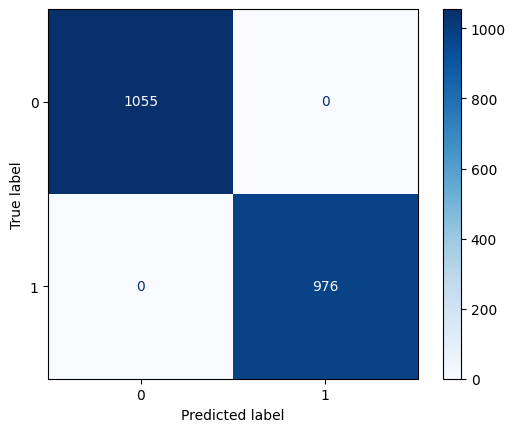

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

predictions = best_rf.predict(X_new)
assert len(y_true) == len(predictions), "разная длина — проверь файл"

cm = confusion_matrix(y_true, predictions, labels=[0, 1])
print(cm)
ConfusionMatrixDisplay(cm, display_labels=[0, 1]).plot(cmap=plt.cm.Blues)
plt.show()

### 📥 Как загрузить файл по ссылке в Colab

Если ваш файл — это таблица (CSV, Excel), вы можете прочитать её напрямую через `pandas`. Если это любой другой файл, его можно скачать в локальное хранилище Colab.

### 📥 Разбор: Загрузка файлов по ссылке в Python

Для автоматизации загрузки данных из внешних ресурсов (например, Stepik) мы использовали связку двух стандартных библиотек: `requests` и `os`.

#### 1. Используемые библиотеки
*   **`requests`**: Это самая популярная библиотека для отправки HTTP-запросов. Мы используем её, чтобы «сходить» по ссылке и забрать содержимое файла.
*   **`os`**: Библиотека для работы с операционной системой. Она помогает нам манипулировать путями к файлам и проверять, существует ли файл в папке `/content/`.

#### 2. Разбор ключевых функций и методов

*   **`requests.get(url)`**: Отправляет запрос к серверу. Если сервер доступен, он возвращает объект `response`.
*   **`response.raise_for_status()`**: Критически важная проверка. Если ссылка битая (ошибка 404) или сервер упал (ошибка 500), этот метод прервет выполнение и сообщит об ошибке, вместо того чтобы создавать пустой файл.
*   **`url.split('/')[-1]`**: Быстрый способ получить имя файла. Например, для ссылки `.../course/524/test.csv` этот метод возьмет последнюю часть после слеша — `test.csv`.
*   **`with open(path, 'wb') as f`**: Открывает файл для записи в бинарном режиме (`wb` — write binary). Это гарантирует, что данные (будь то текст, картинка или таблица) запишутся без искажений.
*   **`os.path.exists(path)`**: Позволяет избежать лишней работы. Если вы запустите ячейку второй раз, скрипт увидит, что файл уже скачан, и не будет тратить время и трафик на повторную загрузку.

#### 3. Алгоритм работы (Step-by-Step)
1.  **Список URL**: Мы создаем массив со всеми нужными ссылками.
2.  **Цикл**: Проходим по каждой ссылке отдельно.
3.  **Имя файла**: Выделяем имя из URL.
4.  **Проверка**: Смотрим, нет ли уже такого файла в Colab.
5.  **Запрос**: Скачиваем содержимое по ссылке.
6.  **Сохранение**: Записываем скачанные байты на «жесткий диск» виртуальной машины Colab.

### 🔄 Шаг 1: Восстановление файлов
Сначала скачаем все файлы, доступные по ссылкам, и подготовим загрузчик для ваших локальных файлов.

In [ ]:
import requests
import os

stepik_urls = [
    'https://stepik.org/media/attachments/course/4852/dogs.csv',
    'https://stepik.org/media/attachments/course/4852/cats.csv',
    'https://stepik.org/media/attachments/course/4852/iris.csv',
    'https://stepik.org/media/attachments/course/4852/train_iris.csv',
    'https://stepik.org/media/attachments/course/4852/test_iris.csv',
    'https://stepik.org/media/attachments/course/4852/dogs_n_cats.csv',
    'https://stepik.org/media/attachments/course/4852/songs.csv',
    'https://stepik.org/media/attachments/course/4852/train_data_tree.csv'
]

for url in stepik_urls:
    filename = url.split('/')[-1]
    response = requests.get(url)
    with open(filename, 'wb') as f:
        f.write(response.content)
    print(f'✅ Скачан: {filename}')

print('\nТеперь, пожалуйста, загрузите недостающие файлы (train.csv, titanic (1).csv, heart-disease.csv и т.д.) через панель слева или выполните следующую ячейку.')

✅ Скачан: dogs.csv
✅ Скачан: cats.csv
✅ Скачан: iris.csv
✅ Скачан: train_iris.csv
✅ Скачан: test_iris.csv
✅ Скачан: dogs_n_cats.csv
✅ Скачан: songs.csv
✅ Скачан: train_data_tree.csv

Теперь, пожалуйста, загрузите недостающие файлы (train.csv, titanic (1).csv, heart-disease.csv и т.д.) через панель слева или выполните следующую ячейку.


In [ ]:
from google.colab import drive
import os

# 1. Монтируем Google Диск
drive.mount('/content/drive')

# 2. Определяем путь к папке (с новым названием)
backup_path = '/content/drive/MyDrive/Stepik_ML_Project_Backup(Tree)'

# 3. Создаем папку, если ее нет
if not os.path.exists(backup_path):
    os.makedirs(backup_path)
    print(f"Папка создана: {backup_path}")

# 4. Определяем список всех файлов для бэкапа (из Stepik и ручных загрузок)
all_files = [
    'dogs.csv', 'cats.csv', 'iris.csv', 'train_iris.csv', 'test_iris.csv',
    'dogs_n_cats.csv', 'songs.csv', 'train_data_tree.csv', 'train.csv',
    'titanic (1).csv', 'heart-disease.csv', 'training_mush.csv',
    'testing_mush.csv', 'mytesting_y_mash.csv'
]

# Добавляем поиск любых .txt файлов (результаты Stepik)
current_files = os.listdir('.')
extra_files = [f for f in current_files if f.endswith('.txt') or 'dataset' in f]
all_files = list(set(all_files + extra_files))

print(f"Готов к копированию {len(all_files)} файлов. Теперь можно запускать следующую ячейку.")

Mounted at /content/drive
Готов к копированию 14 файлов. Теперь можно запускать следующую ячейку.


In [ ]:
from google.colab import files
print('Загрузите файлы: train.csv, titanic (1).csv, heart-disease.csv, training_mush.csv, testing_mush.csv, mytesting_y_mash.csv')
uploaded = files.upload()

Загрузите файлы: train.csv, titanic (1).csv, heart-disease.csv, training_mush.csv, testing_mush.csv, mytesting_y_mash.csv


Saving train.csv to train.csv


### 📤 Шаг 2: Повторный запуск бэкапа
Когда все галочки выше будут стоять и файлы появятся в списке слева, запустите эту ячейку для копирования на Диск.

In [ ]:
import shutil
import os

# Проверка наличия необходимых переменных
try:
    print(f"Целевая папка: {backup_path}\n")

    for file_name in all_files:
        if os.path.exists(file_name):
            shutil.copy(file_name, os.path.join(backup_path, file_name))
            print(f"✅ Успешно скопирован в облако: {file_name}")
        else:
            print(f"❌ Пропущен (не найден локально): {file_name}")

except NameError:
    print("❌ ОШИБКА: Переменные не найдены. Пожалуйста, запустите ячейку выше (jOzI17dI2shb) для инициализации путей!")

Целевая папка: /content/drive/MyDrive/Stepik_ML_Project_Backup(Tree)

✅ Успешно скопирован в облако: dogs.csv
✅ Успешно скопирован в облако: train_iris.csv
✅ Успешно скопирован в облако: dogs_n_cats.csv
✅ Успешно скопирован в облако: cats.csv
✅ Успешно скопирован в облако: train.csv
❌ Пропущен (не найден локально): mytesting_y_mash.csv
✅ Успешно скопирован в облако: train_data_tree.csv
✅ Успешно скопирован в облако: test_iris.csv
✅ Успешно скопирован в облако: titanic (1).csv
❌ Пропущен (не найден локально): heart-disease.csv
✅ Успешно скопирован в облако: songs.csv
✅ Успешно скопирован в облако: iris.csv
✅ Успешно скопирован в облако: training_mush.csv
✅ Успешно скопирован в облако: testing_mush.csv


In [ ]:
# Задание 5

import pandas as pd

invasion_data = pd.read_csv('invasion.csv')
invasion_data.head()




,class,g_reflection,i_reflection,speed,brightness,time_of_observance,volume
0,transport,2.190672,6.716633,62.168208,0.347465,158221,44.932446
1,transport,3.453276,8.995909,62.994707,0.590094,385972,41.568300
2,transport,2.432994,6.938691,62.245807,0.329288,446482,40.123467
3,fighter,6.083763,3.019459,18.474555,0.174738,210125,11.384865
4,fighter,12.876769,2.452950,195.805771,0.150446,23109,11.328806


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X_train = invasion_data.drop('class', axis=1)
y_train = invasion_data['class']

# Параметры для подбора
params = {
    'n_estimators': [10, 20, 30, 40, 50, 100],
    'max_depth': [1, 3, 5, 7, 9, 11],
    'min_samples_leaf': [1, 2, 3, 4, 5, 6, 7],
    'min_samples_split': [2, 4, 6, 8]
}

rf = RandomForestClassifier(random_state=0)

# Запуск поиска по сетке
grid_search = GridSearchCV(rf, params, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая точность: {grid_search.best_score_:.4f}")

In [ ]:
# Задание 5
# Загружаем оперативные данные
X_new = pd.read_csv('operative_information.csv')

# Исправляем вывод классов и делаем предсказание
print(f'Список классов в модели: {best_model.classes_}')

# Предсказываем типы кораблей
predictions = best_model.predict(X_new)

# Считаем количество кораблей каждого типа
from collections import Counter
counts = Counter(predictions)

print("\nРезультаты классификации:")
for ship_type, count in counts.items():
    print(f"- {ship_type}: {count}")

Список классов в модели: ['cruiser' 'fighter' 'transport']

Результаты классификации:
- fighter: 675
- transport: 595
- cruiser: 230


In [ ]:
importance_df = pd.DataFrame(
    best_model.feature_importances_,
    index=X_train.columns,  # ← вот здесь используют x_train.columns
    columns=['importance']
)

#  Сортируем и выводим
importance_df = importance_df.sort_values('importance', ascending=True)
print(importance_df)

                    importance
time_of_observance    0.000000
g_reflection          0.082723
i_reflection          0.124372
speed                 0.171441
volume                0.257661
brightness            0.363803


In [ ]:
import numpy as np

# Исправляем синтаксическую ошибку в f-строке
information_gains = best_model.feature_importances_


print(f'')
print(f'Максимальный IG: {max(information_gains):.3f}')

Максимальный IG: 0.364


In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

X_train = invasion_data.drop('class', axis=1)
y_train = invasion_data['class']

# Обучаем модель с n_estimators = 100 как запрошено
rf = RandomForestClassifier(n_estimators=100, random_state=0)
rf.fit(X_train, y_train)

best_model = rf
print("Модель Random Forest (100 деревьев) успешно обучена.")

Модель Random Forest (100 деревьев) успешно обучена.


In [ ]:
# Задание 6

importance_df = pd.DataFrame(
    rf.feature_importances_,
    index=X_train.columns,  # ← вот здесь используют x_train.columns
    columns=['importance']
)

#  Сортируем и выводим
importance_df = importance_df.sort_values('importance', ascending=True)
print(importance_df)

                    importance
time_of_observance    0.000685
i_reflection          0.093694
speed                 0.117529
g_reflection          0.185294
brightness            0.278944
volume                0.323855


In [ ]:
# Задание 7

import pandas as pd



space_data = pd.read_csv('space_can_be_a_dangerous_place.csv')
space_data.head()
# space_data.info()

,r,phi,peradventure_index,dustiness,black_hole_is_near,buggers_were_noticed,nearby_system_has_planemo,dangerous
0,169.1,138.0,22.3212,0.706285,0,1,1,1
1,11.1,148.0,1.4652,-0.410512,1,1,1,1
2,274.6,201.0,36.2472,0.756457,1,1,1,1
3,172.8,173.0,22.8096,0.035221,1,1,1,1
4,223.3,222.0,29.4756,0.197271,0,1,1,1


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

X = space_data.drop('dangerous', axis=1)
y = space_data['dangerous']


param_grid = {
    'max_depth': [3, 5, 7, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}
# clf = DecisionTreeClassifier(criterion = 'entropy', splitter = "best", max_depth = 5, min_samples_split: int = 2, min_samples_leaf:)

clf = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid,  cv=5, scoring='accuracy')
clf.fit(X, y)




GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [3, 5, 7, None],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [ ]:
# Подбор лучших парметров

print(f'Лучшие параметры: {clf.best_params_}')

best_tree = clf.best_estimator_
print(best_tree)


Лучшие параметры: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}
DecisionTreeClassifier(max_depth=3, random_state=42)


In [ ]:
# Важность признаков

impoprtance = best_tree.feature_importances_

# Создаём датафрейм важности
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
}).sort_values('importance', ascending=False)

print("Feature Importance (from best tree):")
print(importance_df)


Feature Importance (from best tree):
                     feature  importance
5       buggers_were_noticed    0.554931
6  nearby_system_has_planemo    0.427127
4         black_hole_is_near    0.017943
2         peradventure_index    0.000000
1                        phi    0.000000
0                          r    0.000000
3                  dustiness    0.000000


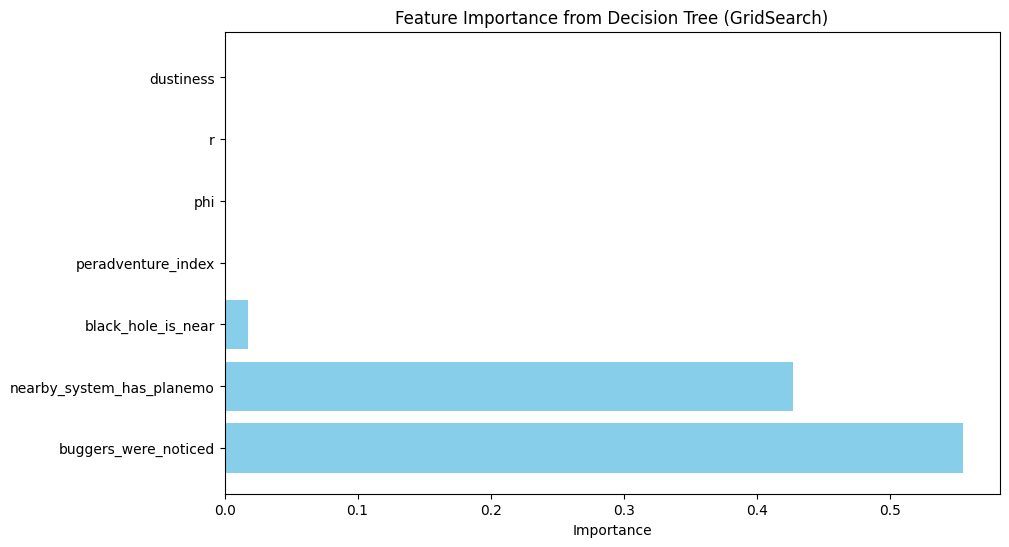

In [ ]:
import matplotlib.pyplot as plt


# Визуализируем через график


# Визуализация
plt.figure(figsize=(10,6))
plt.barh(importance_df['feature'], importance_df['importance'], color='skyblue')
plt.xlabel('Importance')
plt.title('Feature Importance from Decision Tree (GridSearch)')
# plt.gca().invert_yaxis()  # чтобы самый важный был сверху
plt.show()




In [ ]:
from scipy.stats import ttest_ind, mannwhitneyu

# Список количественных признаков (все, кроме целевой)
quant_cols = X.columns.tolist()

results = []
for col in quant_cols:
    group0 = X.loc[y == 0, col].dropna()
    group1 = X.loc[y == 1, col].dropna()

    # Проверка нормальности (опционально) – если хотите выбрать t или U
    # Для простоты используем U-тест (непараметрический)
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    results.append({
        'feature': col,
        'p_value': p,
        'significant': p < 0.05
    })

results_df = pd.DataFrame(results).sort_values('p_value')
print("Результаты U-теста (сравнение опасных vs безопасных):")
print(results_df)

Результаты U-теста (сравнение опасных vs безопасных):
                     feature       p_value  significant
6  nearby_system_has_planemo  0.000000e+00         True
5       buggers_were_noticed  0.000000e+00         True
4         black_hole_is_near  5.666755e-63         True
0                          r  6.758237e-02        False
2         peradventure_index  6.758237e-02        False
1                        phi  3.382945e-01        False
3                  dustiness  8.414128e-01        False
